# ROUND 3 EDA — `HYDROGEL_PACK`, `VELVETFRUIT_EXTRACT`, and 10 `VEV_*` vouchers

Visual exploration of the order-book snapshots (`prices_round_3_day_*.csv`) and executed trades (`trades_round_3_day_*.csv`) in the `3/ROUND_3/` folder.

This round adds a **call-option book** on top of the usual delta-1 microstructure:

- **Spot:** `VELVETFRUIT_EXTRACT` (≈ 5,250 — the underlying for all vouchers), `HYDROGEL_PACK` (independent, ≈ 10,000).
- **Vouchers:** 10 European calls on VEV — `VEV_4000`, `VEV_4500`, `VEV_5000`, `VEV_5100`, `VEV_5200`, `VEV_5300`, `VEV_5400`, `VEV_5500`, `VEV_6000`, `VEV_6500`.

**TTE convention.** 7-day expiry from start of Round 1. Historical TTE: day 0 = 8d, day 1 = 7d, day 2 = 6d. Within a day, TTE decays linearly from `Nd` to `(N-1)d` over 1,000,000 timestamps. Black–Scholes uses `T = TTE_days / 252`.

**Sections**

0. Setup, helpers, data load
1. Per-product summary table
2. Mid-price time series
3. Spread, depth, liquidity tiers
4. Returns & realized vol
5. Cross-product structure
6. **Options analytics — the alpha core**
7. Spot-side microstructure
8. Takeaways


## 0. Setup, helpers, data load

In [38]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.stats import norm
from scipy.interpolate import CubicSpline

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

# Locate data folder.
_candidates = [Path("3/ROUND_3"), Path("ROUND3"), Path(".")]
DATA_DIR = next((c for c in _candidates if list(c.glob("prices_round_3_day_*.csv"))), Path("3/ROUND_3"))
print("data dir:", DATA_DIR.resolve())

# Product groups.
PRODUCT_SPOT = ["VELVETFRUIT_EXTRACT", "HYDROGEL_PACK"]
VOUCHER_STRIKES = {
    "VEV_4000": 4000, "VEV_4500": 4500,
    "VEV_5000": 5000, "VEV_5100": 5100, "VEV_5200": 5200,
    "VEV_5300": 5300, "VEV_5400": 5400, "VEV_5500": 5500,
    "VEV_6000": 6000, "VEV_6500": 6500,
}
VOUCHERS = list(VOUCHER_STRIKES.keys())
ALL_PRODUCTS = PRODUCT_SPOT + VOUCHERS
UNDERLYING = "VELVETFRUIT_EXTRACT"

# Color maps.
SPOT_COLOR = {"VELVETFRUIT_EXTRACT": "#1f77b4", "HYDROGEL_PACK": "#d62728"}
_v_norm = (np.array(list(VOUCHER_STRIKES.values())) - 4000) / (6500 - 4000)
VOUCHER_COLOR = {v: cm.viridis(x) for v, x in zip(VOUCHERS, _v_norm)}
COLOR = {**SPOT_COLOR, **VOUCHER_COLOR}

# TTE convention.
EXPIRY_DAYS_AT_DAY0 = 8.0   # historical day 0 == TTE 8d
DAYS_PER_YEAR = 252.0

def tte_years_from_t(t_arr):
    """t = day*1e6 + ts. TTE = (8 - t/1e6) days."""
    return (EXPIRY_DAYS_AT_DAY0 - np.asarray(t_arr) / 1_000_000.0) / DAYS_PER_YEAR


data dir: /Users/Satria/Desktop/Coding/PROSPERITY/asimc4/3/ROUND_3


In [39]:
def load_prices(folder: Path) -> pd.DataFrame:
    frames = [pd.read_csv(p, sep=";") for p in sorted(folder.glob("prices_round_3_day_*.csv"))]
    df = pd.concat(frames, ignore_index=True)
    day_offset = (df["day"] - df["day"].min()) * 1_000_000
    df["t"] = day_offset + df["timestamp"]
    return df.sort_values(["t", "product"]).reset_index(drop=True)

def load_trades(folder: Path) -> pd.DataFrame:
    frames = []
    for p in sorted(folder.glob("trades_round_3_day_*.csv")):
        d = pd.read_csv(p, sep=";")
        d["day"] = int(str(p).split("day_")[-1].split(".")[0])
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)
    day_offset = (df["day"] - df["day"].min()) * 1_000_000
    df["t"] = day_offset + df["timestamp"]
    return df.sort_values("t").reset_index(drop=True)

def pivot_mid(df: pd.DataFrame, products) -> pd.DataFrame:
    m = df[df["product"].isin(products)].pivot_table(
        index="t", columns="product", values="mid_price", aggfunc="last"
    )
    return m.sort_index().ffill()  # keep NaN at the very start

def acf(x, lags=30):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    x = x - x.mean()
    v = float(np.dot(x, x))
    if v < 1e-20:
        return np.full(lags + 1, np.nan)
    return np.array([np.dot(x[: len(x) - k], x[k:]) / v for k in range(lags + 1)])

def agg_imb(df, kmax):
    bv = sum(df[f"bid_volume_{k}"].fillna(0) for k in range(1, kmax + 1))
    av = sum(df[f"ask_volume_{k}"].fillna(0) for k in range(1, kmax + 1))
    return (bv - av) / (bv + av).replace(0, np.nan)

prices = load_prices(DATA_DIR)
trades = load_trades(DATA_DIR)
print("prices rows:", len(prices), "| days:", sorted(prices['day'].unique()))
print("trades rows:", len(trades), "| symbols:", sorted(trades['symbol'].unique()))
prices.head()


prices rows: 360000 | days: [0, 1, 2]
trades rows: 4048 | symbols: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss,t
0,0,0,HYDROGEL_PACK,9992,15,9990.0,30.0,NaN,NaN,10008,15,10010.0,30.0,NaN,NaN,10000.0,0.0,0
1,0,0,VELVETFRUIT_EXTRACT,5247,67,NaN,NaN,NaN,NaN,5253,67,NaN,NaN,NaN,NaN,5250.0,0.0,0
2,0,0,VEV_4000,1240,7,1237.0,24.0,NaN,NaN,1260,7,1263.0,24.0,NaN,NaN,1250.0,0.0,0
3,0,0,VEV_4500,742,6,740.0,13.0,NaN,NaN,758,6,760.0,13.0,NaN,NaN,750.0,0.0,0
4,0,0,VEV_5000,254,19,NaN,NaN,NaN,NaN,260,6,261.0,13.0,NaN,NaN,257.0,0.0,0


In [40]:
# Black-Scholes call pricing & implied vol (vectorized Newton).
def bs_d1(S, K, T, sigma):
    return (np.log(S / K) + 0.5 * sigma * sigma * T) / (sigma * np.sqrt(T))

def bs_call_price(S, K, T, sigma):
    S, K, T, sigma = [np.asarray(x, dtype=float) for x in (S, K, T, sigma)]
    d1 = bs_d1(S, K, T, sigma)
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * norm.cdf(d2)

def bs_vega(S, K, T, sigma):
    S, K, T, sigma = [np.asarray(x, dtype=float) for x in (S, K, T, sigma)]
    d1 = bs_d1(S, K, T, sigma)
    return S * norm.pdf(d1) * np.sqrt(T)

def bs_greeks(S, K, T, sigma):
    """Return (delta, gamma, vega) — all vectorized."""
    S, K, T, sigma = [np.asarray(x, dtype=float) for x in (S, K, T, sigma)]
    d1 = bs_d1(S, K, T, sigma)
    delta = norm.cdf(d1)
    gamma = norm.pdf(d1) / (S * sigma * np.sqrt(T))
    vega  = S * norm.pdf(d1) * np.sqrt(T)
    return delta, gamma, vega

def implied_vol_vec(price, S, K, T, n_iter=60, tol=1e-6, vega_floor=0.5, sigma_init=0.30):
    """Vectorized Newton solver. Returns NaN where below intrinsic+eps or vega is too small."""
    price = np.asarray(price, dtype=float)
    S = np.asarray(S, dtype=float)
    T = np.asarray(T, dtype=float)
    K = float(K)
    intrinsic = np.maximum(S - K, 0.0)
    bad = (~np.isfinite(price)) | (price <= intrinsic + 0.5) | (T <= 0)
    sigma = np.full_like(price, sigma_init)
    sigma[bad] = np.nan
    for _ in range(n_iter):
        sig = np.where(bad, sigma_init, sigma)
        d1 = (np.log(np.where(S > 0, S, 1) / K) + 0.5 * sig * sig * T) / (sig * np.sqrt(T))
        d2 = d1 - sig * np.sqrt(T)
        p_calc = S * norm.cdf(d1) - K * norm.cdf(d2)
        vega = S * norm.pdf(d1) * np.sqrt(T)
        diff = p_calc - price
        step = diff / np.where(vega > 1e-10, vega, 1e-10)
        new_sigma = np.clip(sig - step, 1e-4, 5.0)
        if np.nanmax(np.abs(new_sigma - sig)) < tol:
            sigma = np.where(bad, np.nan, new_sigma)
            break
        sigma = np.where(bad, np.nan, new_sigma)
    # Drop low-vega solutions: they are unreliable (deep ITM/OTM).
    final_vega = bs_vega(S, K, T, np.where(np.isnan(sigma), sigma_init, sigma))
    sigma = np.where(final_vega < vega_floor, np.nan, sigma)
    return sigma


In [41]:
# Tick-size sanity check per product.
print("price granularity (smallest non-zero diff between unique mids, in price units):")
for prod in ALL_PRODUCTS:
    sub = prices.loc[prices["product"] == prod, "mid_price"].dropna().unique()
    if len(sub) < 2:
        continue
    diffs = np.diff(np.sort(sub))
    diffs = diffs[diffs > 0]
    g = float(diffs.min()) if len(diffs) else float("nan")
    n_unique = len(sub)
    print(f"  {prod:<22}  granularity={g:>6.3f}   n_unique_mids={n_unique:>4}   range=[{sub.min():>9.2f}, {sub.max():>9.2f}]")


price granularity (smallest non-zero diff between unique mids, in price units):
  VELVETFRUIT_EXTRACT     granularity= 0.500   n_unique_mids= 199   range=[  5198.00,   5300.00]
  HYDROGEL_PACK           granularity= 0.500   n_unique_mids= 368   range=[  9891.00,  10079.00]
  VEV_4000                granularity= 0.500   n_unique_mids= 196   range=[  1198.00,   1300.00]
  VEV_4500                granularity= 0.500   n_unique_mids= 190   range=[   698.50,    799.50]
  VEV_5000                granularity= 0.500   n_unique_mids= 178   range=[   206.50,    300.50]
  VEV_5100                granularity= 0.500   n_unique_mids= 156   range=[   125.00,    205.50]
  VEV_5200                granularity= 0.500   n_unique_mids= 118   range=[    64.00,    122.50]
  VEV_5300                granularity= 0.500   n_unique_mids=  79   range=[    26.50,     65.50]
  VEV_5400                granularity= 0.500   n_unique_mids=  42   range=[     6.50,     27.00]
  VEV_5500                granularity= 0.500   

## 1. Per-product summary table

One row per product. `sigma_bps_per_tick` = std of log-returns × 1e4 — the cheapest cross-product volatility ranking. Vouchers with very low values are typically the deep-OTM strikes whose mid sits at a single tick most of the time.

In [42]:
rows = []
day_breaks = sorted(prices["day"].unique())
day_bounds = [(d - min(day_breaks)) * 1_000_000 for d in day_breaks]

for prod in ALL_PRODUCTS:
    sub = prices[prices["product"] == prod].copy()
    valid = sub[sub["mid_price"] > 0]
    spread = (sub["ask_price_1"] - sub["bid_price_1"]).dropna()
    depth_top = (sub["ask_volume_1"].fillna(0) + sub["bid_volume_1"].fillna(0))
    if len(valid) > 1:
        logret = np.log(valid["mid_price"]).diff().dropna()
        sigma_bps = float(logret.std()) * 1e4
    else:
        sigma_bps = np.nan
    tr = trades[trades["symbol"] == prod]
    rows.append(dict(
        product=prod,
        n_ticks=len(sub),
        n_valid=len(valid),
        mid_min=valid["mid_price"].min() if len(valid) else np.nan,
        mid_max=valid["mid_price"].max() if len(valid) else np.nan,
        mid_last=float(valid["mid_price"].iloc[-1]) if len(valid) else np.nan,
        mean_spread=float(spread.mean()) if len(spread) else np.nan,
        median_spread=float(spread.median()) if len(spread) else np.nan,
        mean_depth_top=float(depth_top.mean()),
        sigma_bps_per_tick=sigma_bps,
        n_trades=len(tr),
        gross_traded_qty=int(tr["quantity"].sum()) if len(tr) else 0,
    ))

summary = pd.DataFrame(rows).set_index("product").reindex(ALL_PRODUCTS)
summary_disp = summary.copy()
for c in ["mid_min", "mid_max", "mid_last", "mean_spread", "median_spread", "mean_depth_top", "sigma_bps_per_tick"]:
    summary_disp[c] = summary_disp[c].round(3)
summary_disp


,n_ticks,n_valid,mid_min,mid_max,mid_last,mean_spread,median_spread,mean_depth_top,sigma_bps_per_tick,n_trades,gross_traded_qty
product,,,,,,,,,,,
VELVETFRUIT_EXTRACT,30000,30000,5198.0,5300.0,5295.5,4.988,5.0,75.626,2.155,1372,8269
HYDROGEL_PACK,30000,30000,9891.0,10079.0,10010.0,15.721,16.0,24.799,2.172,1010,4078
VEV_4000,30000,30000,1198.0,1300.0,1295.0,20.813,21.0,21.841,11.338,464,940
VEV_4500,30000,30000,698.5,799.5,795.5,15.853,16.0,17.900,16.706,1,1
VEV_5000,30000,30000,206.5,300.5,296.5,6.043,6.0,30.810,38.613,1,1
VEV_5100,30000,30000,125.0,205.5,201.5,4.296,4.0,38.596,51.541,1,1
VEV_5200,30000,30000,64.0,122.5,119.0,2.888,3.0,45.072,72.245,18,63
VEV_5300,30000,30000,26.5,65.5,58.0,2.107,2.0,40.527,108.587,121,420
VEV_5400,30000,30000,6.5,27.0,20.0,1.381,1.0,43.482,177.246,225,787


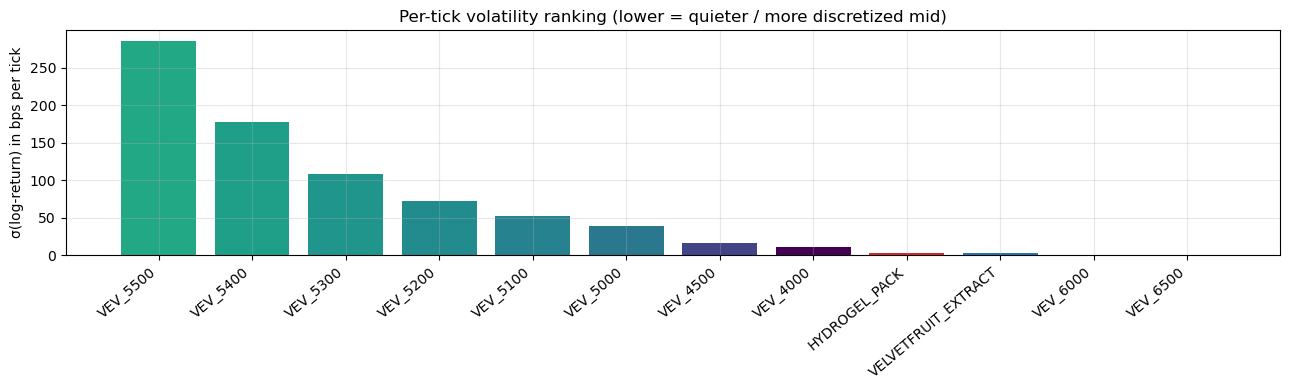

In [43]:
# Bar chart: sigma_bps_per_tick ranked.
ranked = summary["sigma_bps_per_tick"].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(13, 4))
colors = [COLOR.get(p, "#888") for p in ranked.index]
ax.bar(range(len(ranked)), ranked.values, color=colors)
ax.set_xticks(range(len(ranked)))
ax.set_xticklabels(ranked.index, rotation=40, ha="right")
ax.set_ylabel("σ(log-return) in bps per tick")
ax.set_title("Per-tick volatility ranking (lower = quieter / more discretized mid)")
plt.tight_layout(); plt.show()


## 2. Mid-price time series

Three views: spot pair on twin axes, all 10 voucher mids overlaid (color = strike), then a 5×2 detail grid.

mids shape: (30000, 12) | columns: ['HYDROGEL_PACK', 'VELVETFRUIT_EXTRACT', 'VEV_4000', 'VEV_4500', 'VEV_5000', 'VEV_5100', 'VEV_5200', 'VEV_5300', 'VEV_5400', 'VEV_5500', 'VEV_6000', 'VEV_6500']


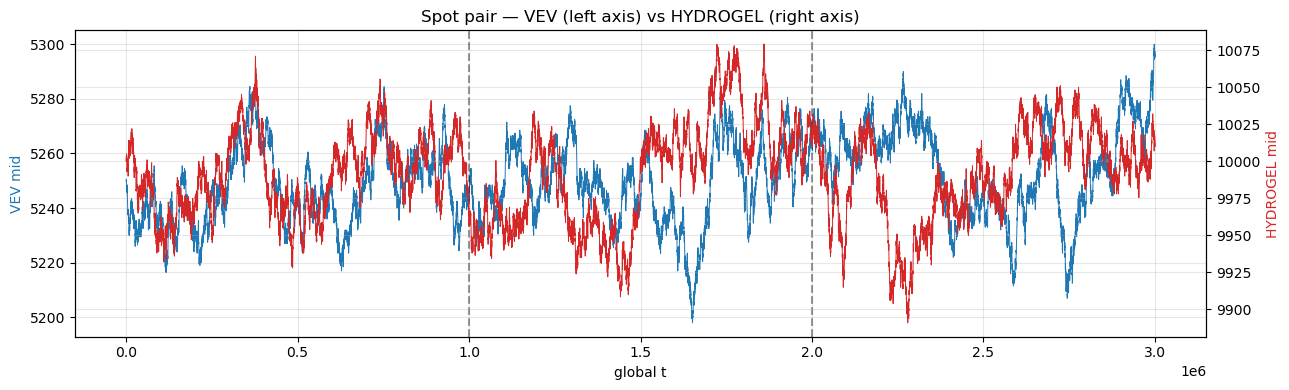

In [44]:
mids = pivot_mid(prices, ALL_PRODUCTS)
print("mids shape:", mids.shape, "| columns:", list(mids.columns))

fig, ax1 = plt.subplots(figsize=(13, 4))
ax2 = ax1.twinx()
ax1.plot(mids.index, mids[UNDERLYING], color=SPOT_COLOR[UNDERLYING], lw=0.7, label=UNDERLYING)
ax2.plot(mids.index, mids["HYDROGEL_PACK"], color=SPOT_COLOR["HYDROGEL_PACK"], lw=0.7, label="HYDROGEL_PACK")
ax1.set_ylabel("VEV mid", color=SPOT_COLOR[UNDERLYING])
ax2.set_ylabel("HYDROGEL mid", color=SPOT_COLOR["HYDROGEL_PACK"])
ax1.set_title("Spot pair — VEV (left axis) vs HYDROGEL (right axis)")
for b in day_bounds[1:]:
    ax1.axvline(b, color="k", ls="--", alpha=0.4)
ax1.set_xlabel("global t")
plt.tight_layout(); plt.show()


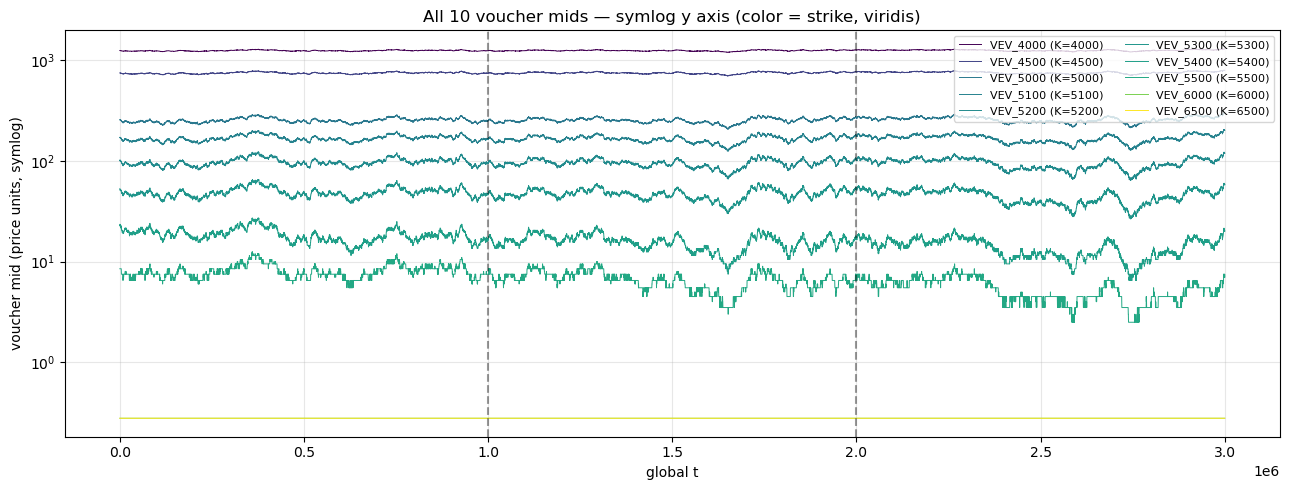

In [45]:
# Voucher overlay with strike-coloured viridis.
fig, ax = plt.subplots(figsize=(13, 5))
for v in VOUCHERS:
    ax.plot(mids.index, mids[v], color=VOUCHER_COLOR[v], lw=0.7, label=f"{v} (K={VOUCHER_STRIKES[v]})")
ax.set_yscale("symlog", linthresh=1.0)
for b in day_bounds[1:]:
    ax.axvline(b, color="k", ls="--", alpha=0.4)
ax.set_title("All 10 voucher mids — symlog y axis (color = strike, viridis)")
ax.set_xlabel("global t"); ax.set_ylabel("voucher mid (price units, symlog)")
ax.legend(loc="upper right", fontsize=8, ncol=2)
plt.tight_layout(); plt.show()


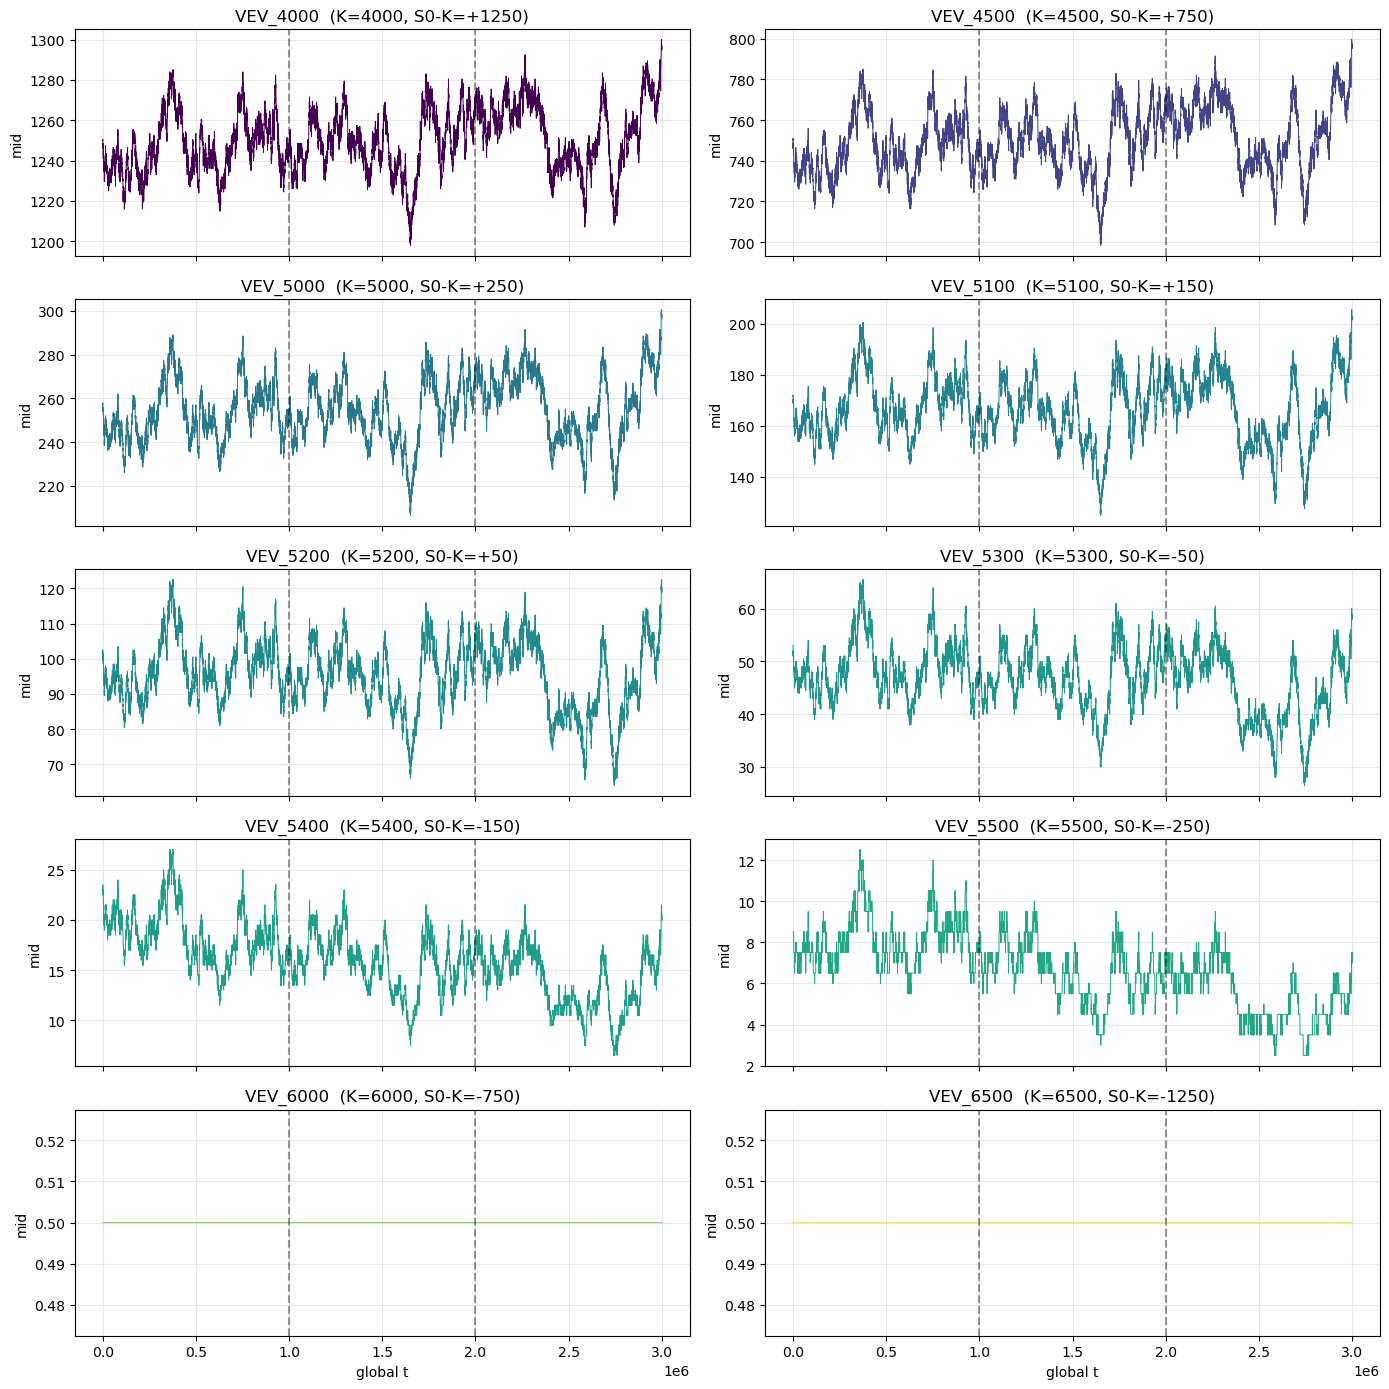

In [46]:
# 5x2 detail grid, one panel per voucher.
fig, axes = plt.subplots(5, 2, figsize=(14, 14), sharex=True)
for i, v in enumerate(VOUCHERS):
    ax = axes[i // 2, i % 2]
    ax.plot(mids.index, mids[v], color=VOUCHER_COLOR[v], lw=0.7)
    K = VOUCHER_STRIKES[v]
    moneyness_at_start = mids[UNDERLYING].iloc[0] - K if pd.notna(mids[UNDERLYING].iloc[0]) else np.nan
    ax.set_title(f"{v}  (K={K}, S0-K={moneyness_at_start:+.0f})")
    ax.set_ylabel("mid")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[-1, 0].set_xlabel("global t"); axes[-1, 1].set_xlabel("global t")
plt.tight_layout(); plt.show()


## 3. Spread, depth, liquidity tiers

The deep-ITM vouchers (`VEV_4000`, `VEV_4500`) and deep-OTM vouchers (`VEV_6000`, `VEV_6500`) are expected to be *much* less liquid than the near-ATM strikes. Histograms below confirm which strikes are tradable in size.

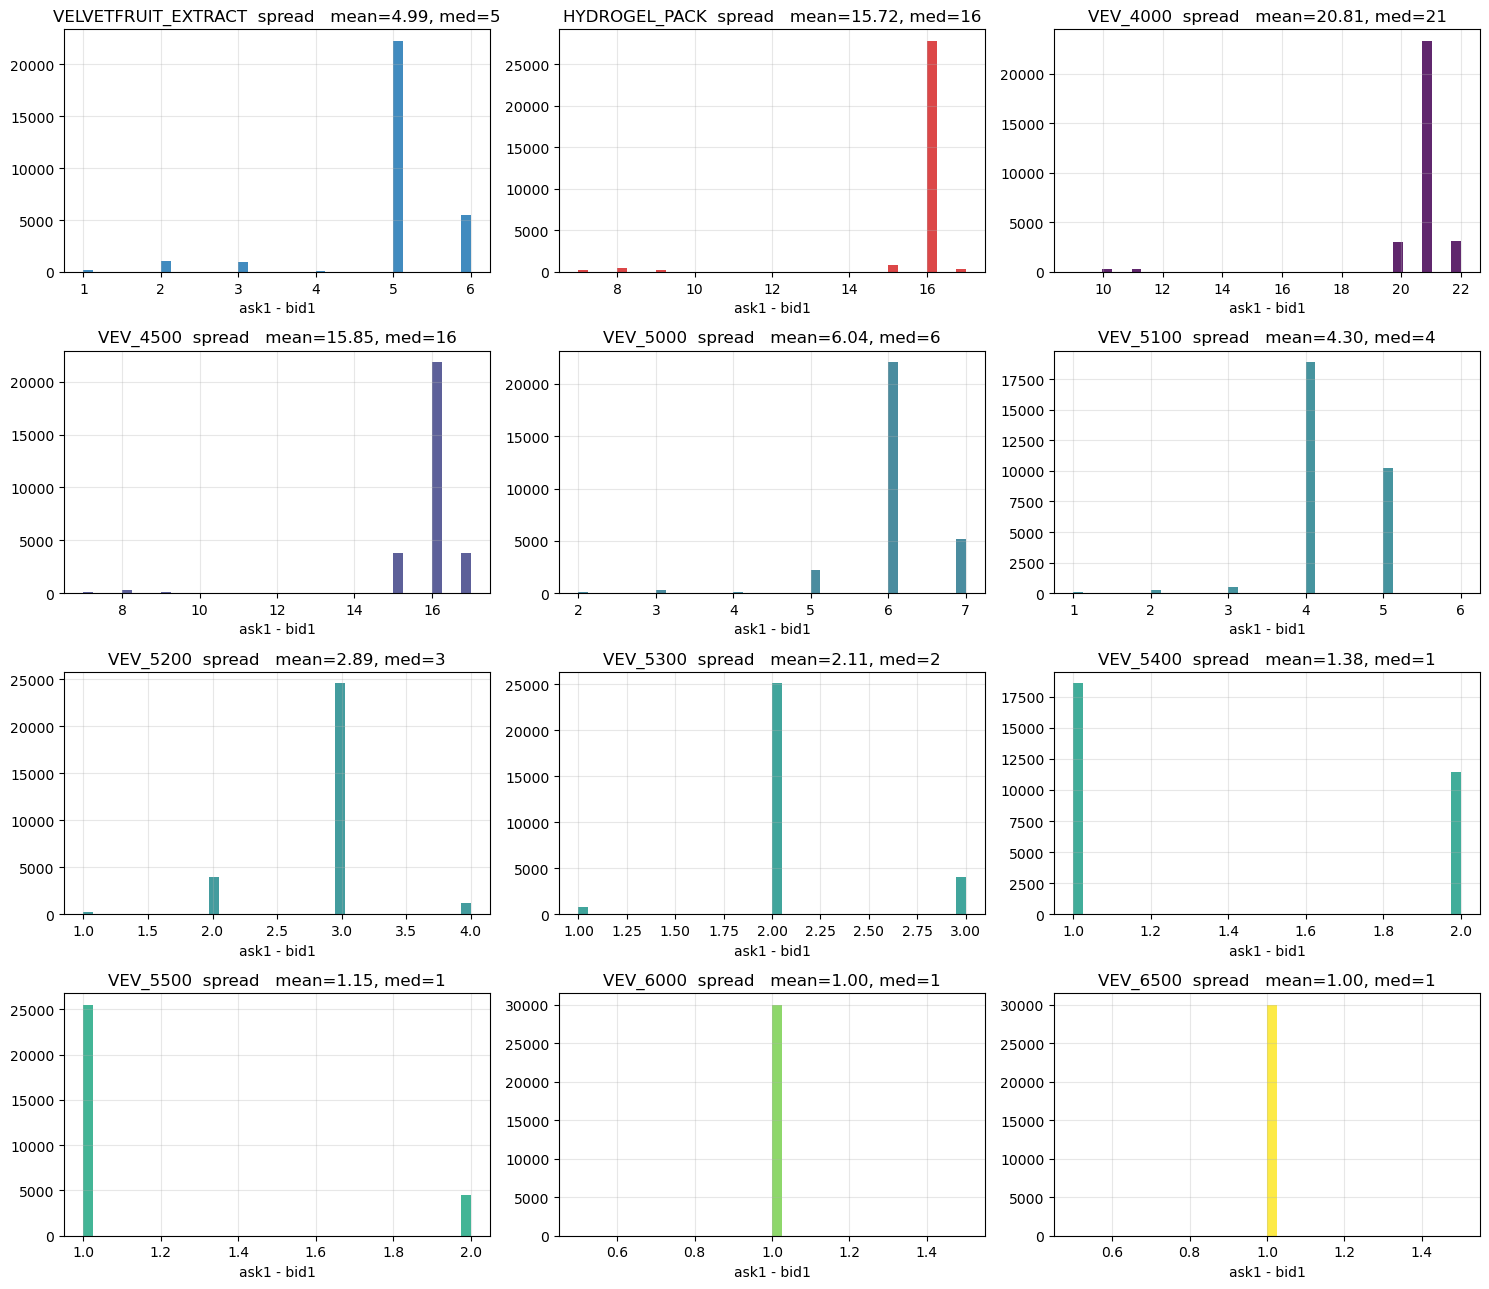

In [47]:
# 4x3 grid of spread histograms.
fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for i, prod in enumerate(ALL_PRODUCTS):
    ax = axes[i // 3, i % 3]
    sub = prices[prices["product"] == prod]
    spr = (sub["ask_price_1"] - sub["bid_price_1"]).dropna()
    if len(spr) == 0:
        ax.set_title(f"{prod} — no data"); continue
    ax.hist(spr, bins=40, color=COLOR.get(prod, "#666"), alpha=0.85)
    ax.set_title(f"{prod}  spread   mean={spr.mean():.2f}, med={spr.median():.0f}")
    ax.set_xlabel("ask1 - bid1")
plt.tight_layout(); plt.show()


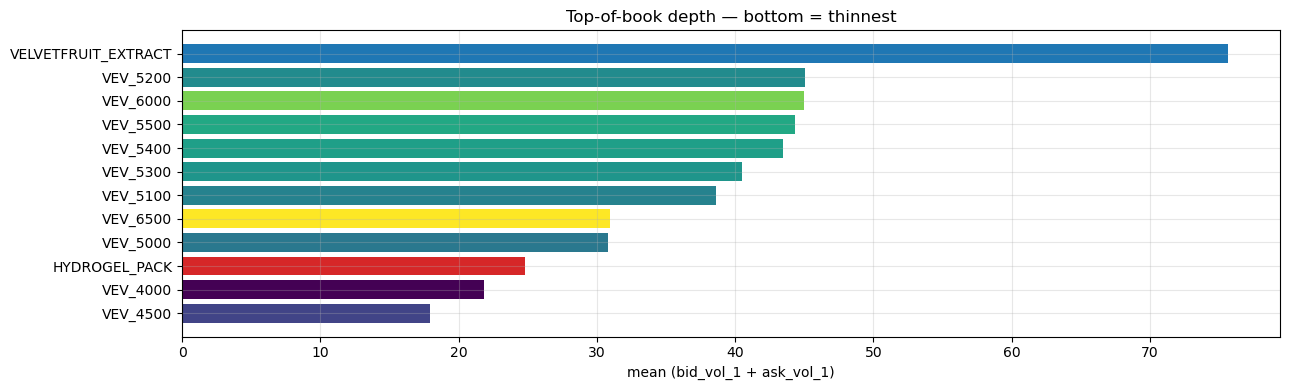


One-sided book frequency:
                     %_no_bid  %_no_ask
product                                
VELVETFRUIT_EXTRACT       0.0       0.0
HYDROGEL_PACK             0.0       0.0
VEV_4000                  0.0       0.0
VEV_4500                  0.0       0.0
VEV_5000                  0.0       0.0
VEV_5100                  0.0       0.0
VEV_5200                  0.0       0.0
VEV_5300                  0.0       0.0
VEV_5400                  0.0       0.0
VEV_5500                  0.0       0.0
VEV_6000                  0.0       0.0
VEV_6500                  0.0       0.0


In [48]:
# Mean depth ranked.
depth_ranked = summary["mean_depth_top"].sort_values()
fig, ax = plt.subplots(figsize=(13, 4))
colors = [COLOR.get(p, "#888") for p in depth_ranked.index]
ax.barh(range(len(depth_ranked)), depth_ranked.values, color=colors)
ax.set_yticks(range(len(depth_ranked)))
ax.set_yticklabels(depth_ranked.index)
ax.set_xlabel("mean (bid_vol_1 + ask_vol_1)")
ax.set_title("Top-of-book depth — bottom = thinnest")
plt.tight_layout(); plt.show()

# % one-sided ticks per product.
one_sided = []
for prod in ALL_PRODUCTS:
    sub = prices[prices["product"] == prod]
    n = len(sub)
    no_bid = sub["bid_price_1"].isna().sum()
    no_ask = sub["ask_price_1"].isna().sum()
    one_sided.append({
        "product": prod, "%_no_bid": 100 * no_bid / n if n else np.nan,
        "%_no_ask": 100 * no_ask / n if n else np.nan,
    })
print("\nOne-sided book frequency:")
print(pd.DataFrame(one_sided).set_index("product").round(2))


## 4. Returns & realized vol

Per-product return distributions plus the realized vol of the underlying — the input we'll compare to implied vol later.

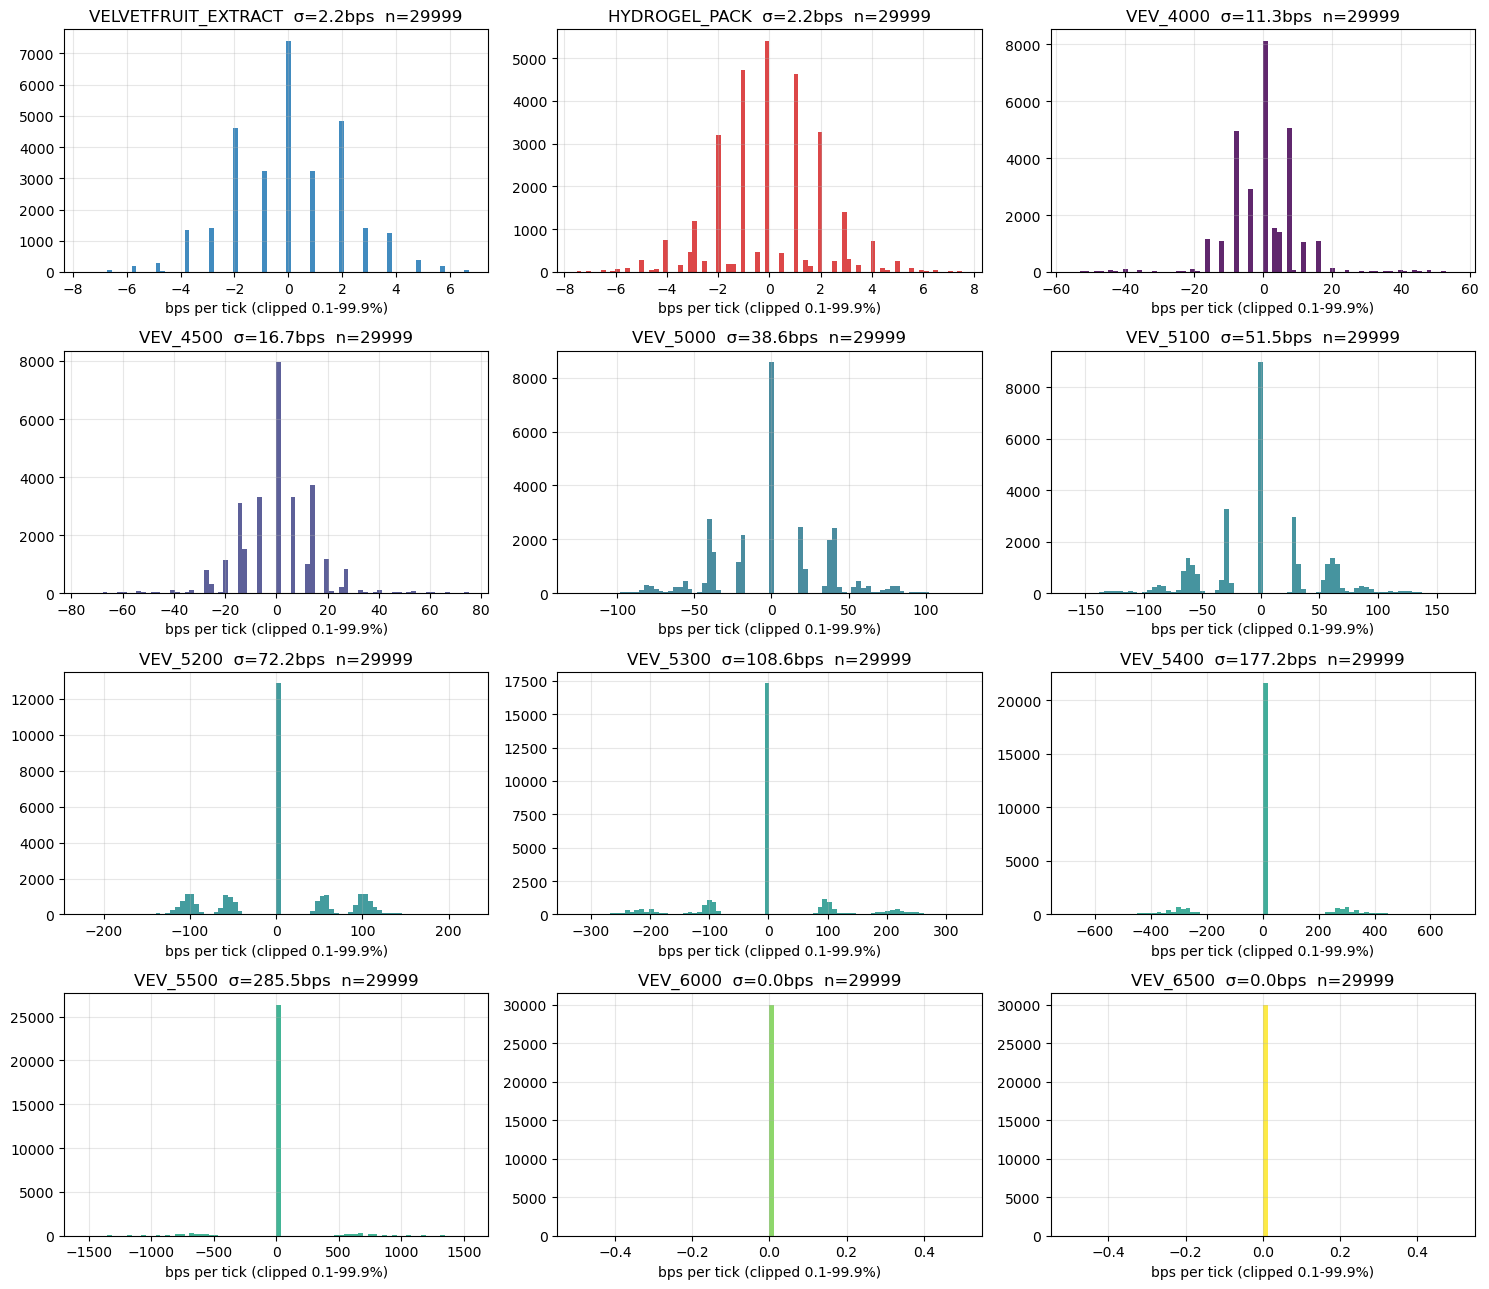

In [49]:
mids_pos = mids.where(mids > 0)
rets = np.log(mids_pos).diff() * 1e4  # bps
rets = rets.replace([np.inf, -np.inf], np.nan)

fig, axes = plt.subplots(4, 3, figsize=(15, 13))
for i, prod in enumerate(ALL_PRODUCTS):
    ax = axes[i // 3, i % 3]
    x = rets[prod].dropna().values
    if x.size == 0:
        ax.set_title(f"{prod} — no returns"); continue
    lo, hi = np.quantile(x, [0.001, 0.999])
    xc = x[(x >= lo) & (x <= hi)] if hi > lo else x
    ax.hist(xc, bins=80, color=COLOR.get(prod, "#666"), alpha=0.85)
    ax.set_title(f"{prod}  σ={x.std():.1f}bps  n={len(x)}")
    ax.set_xlabel("bps per tick (clipped 0.1-99.9%)")
plt.tight_layout(); plt.show()


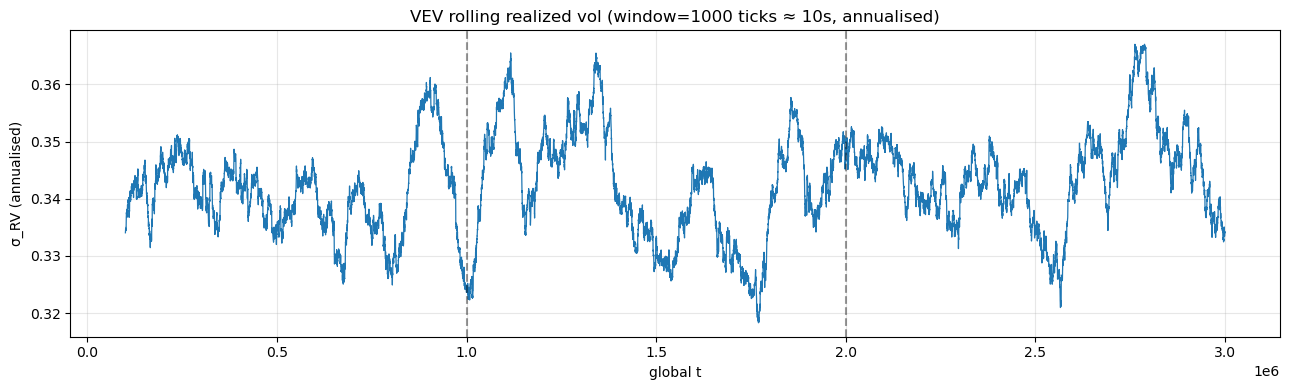

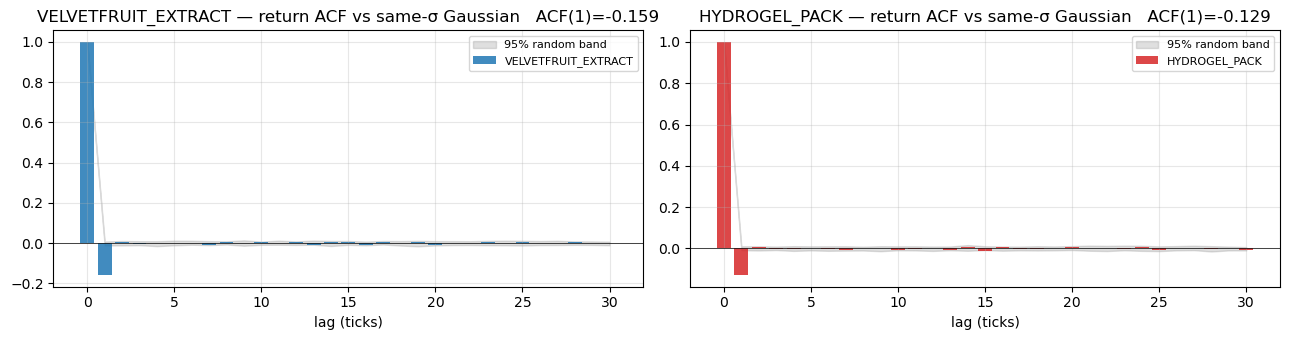

In [50]:
# Rolling realized vol of VEV underlying, annualised.
WIN = 1000
ticks_per_day = 1_000_000 / 100  # snapshot every 100 ts -> 10,000 ticks/day
ann = np.sqrt(DAYS_PER_YEAR * ticks_per_day)

vev_logret = np.log(mids_pos[UNDERLYING]).diff()
rv_ann = vev_logret.rolling(WIN).std() * ann

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(rv_ann.index, rv_ann.values, color=SPOT_COLOR[UNDERLYING], lw=0.9)
for b in day_bounds[1:]:
    ax.axvline(b, color="k", ls="--", alpha=0.4)
ax.set_title(f"VEV rolling realized vol (window={WIN} ticks ≈ {WIN/100:.0f}s, annualised)")
ax.set_ylabel("σ_RV (annualised)"); ax.set_xlabel("global t")
plt.tight_layout(); plt.show()

# Returns ACF for the two spot products, overlaid against ACF of a same-σ Gaussian baseline.
# Last year's mean-reversion validation: real ACF should sit clearly outside the random band.
RNG = np.random.default_rng(0)
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, prod in zip(axes, PRODUCT_SPOT):
    real = rets[prod].dropna().values
    a_real = acf(real, 30)
    # 50 random gaussians with the same length and σ; plot mean ± 2σ band.
    n = len(real); sigma_p = real.std()
    rand_acfs = np.array([acf(RNG.standard_normal(n) * sigma_p, 30) for _ in range(50)])
    lo, hi = np.quantile(rand_acfs, [0.025, 0.975], axis=0)
    ax.fill_between(range(31), lo, hi, color="grey", alpha=0.25, label="95% random band")
    ax.bar(range(31), a_real, color=SPOT_COLOR[prod], alpha=0.85, label=prod)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{prod} — return ACF vs same-σ Gaussian   ACF(1)={a_real[1]:+.3f}")
    ax.set_xlabel("lag (ticks)"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


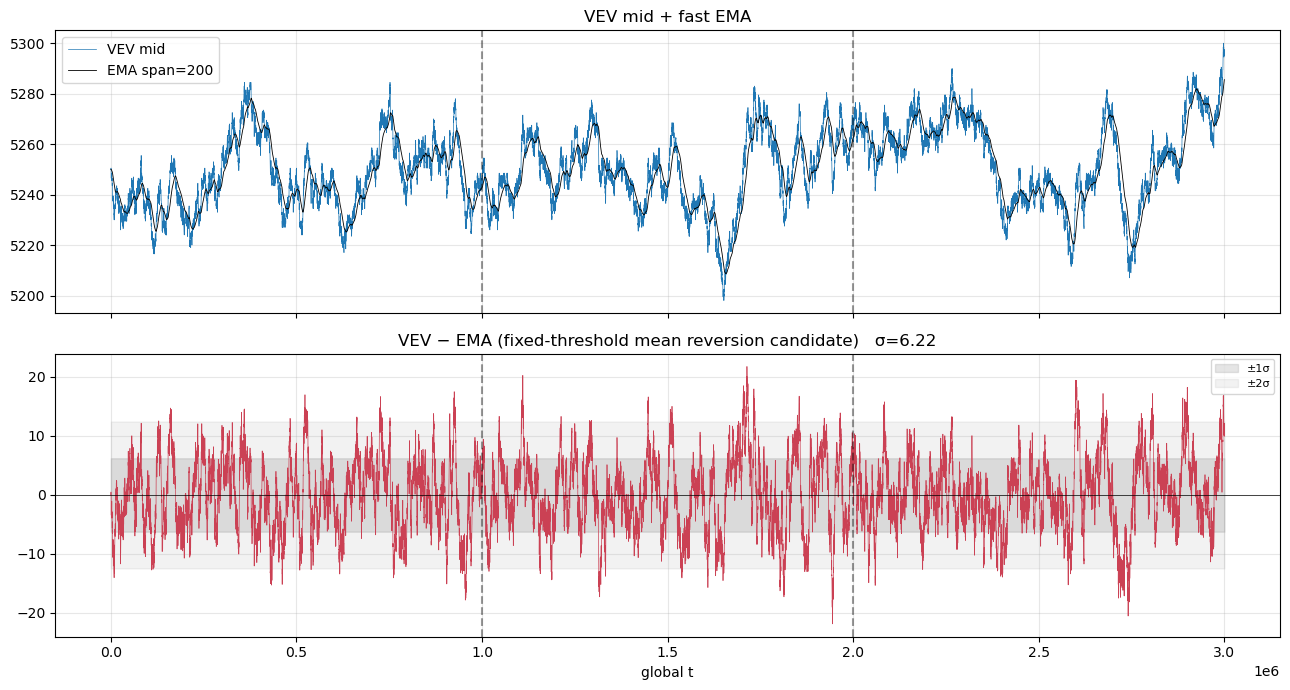

In [51]:
# EMA-based mean-reversion view of VEV (matches last year's winner's secondary trade).
EMA_FAST = 200
ema = mids_pos[UNDERLYING].ewm(span=EMA_FAST, adjust=False).mean()
dev = mids_pos[UNDERLYING] - ema

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
axes[0].plot(mids.index, mids_pos[UNDERLYING], color=SPOT_COLOR[UNDERLYING], lw=0.5, label="VEV mid")
axes[0].plot(ema.index, ema.values, color="k", lw=0.6, label=f"EMA span={EMA_FAST}")
axes[0].set_title("VEV mid + fast EMA"); axes[0].legend()
axes[1].plot(dev.index, dev.values, color="#cb4154", lw=0.5)
axes[1].axhline(0, color="k", lw=0.5)
axes[1].fill_between(dev.index, -dev.std(), dev.std(), color="grey", alpha=0.2, label="±1σ")
axes[1].fill_between(dev.index, -2*dev.std(), 2*dev.std(), color="grey", alpha=0.1, label="±2σ")
axes[1].set_title(f"VEV − EMA (fixed-threshold mean reversion candidate)   σ={dev.std():.2f}")
axes[1].legend(fontsize=8); axes[1].set_xlabel("global t")
for b in day_bounds[1:]:
    for a in axes:
        a.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout(); plt.show()


## 5. Cross-product structure

How do the 12 products move together? The 12×12 returns-correlation heatmap should show: HYDROGEL essentially independent (its own asset class), VEV strongly correlated with the deep-ITM vouchers (delta ≈ 1) and weakly correlated with the deep-OTM ones (low delta + lots of noise).

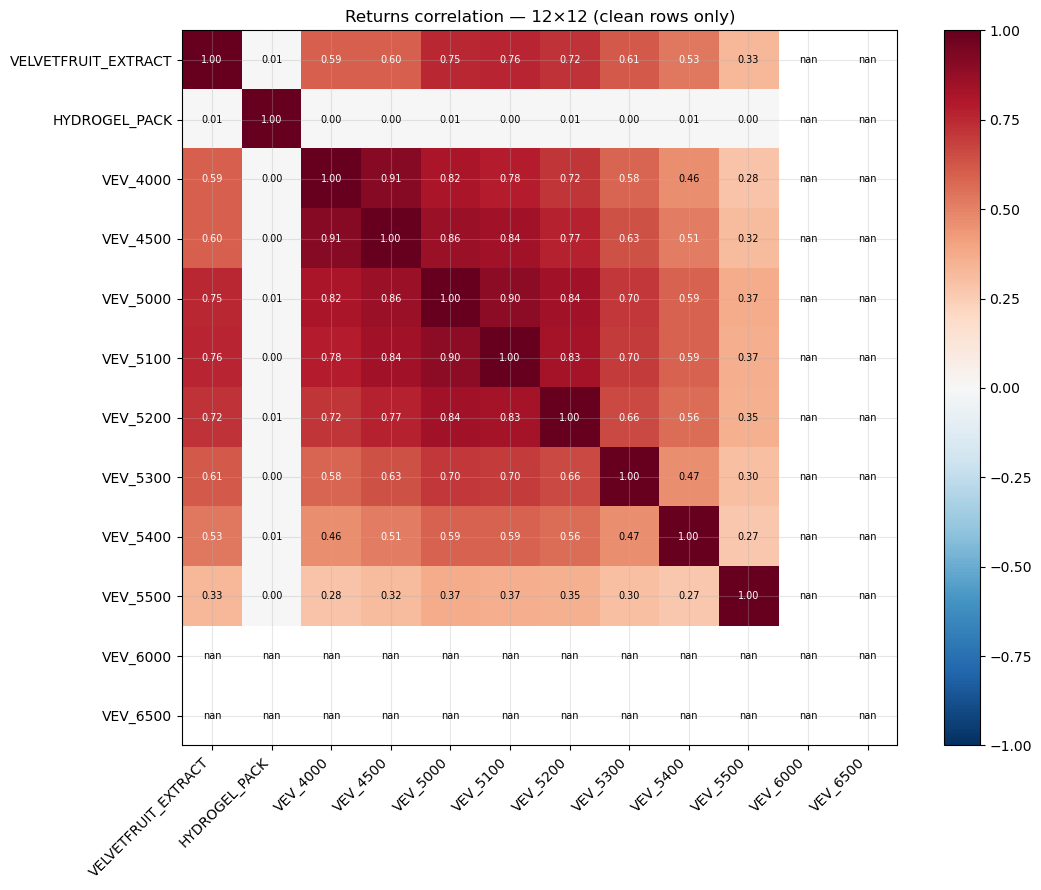

In [52]:
rets_clean = rets.dropna(how="all")
order = PRODUCT_SPOT + VOUCHERS
corr = rets_clean[order].corr()

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(order))); ax.set_xticklabels(order, rotation=45, ha="right")
ax.set_yticks(range(len(order))); ax.set_yticklabels(order)
for i in range(len(order)):
    for j in range(len(order)):
        ax.text(j, i, f"{corr.values[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="white" if abs(corr.values[i,j]) > 0.5 else "black")
ax.set_title("Returns correlation — 12×12 (clean rows only)")
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


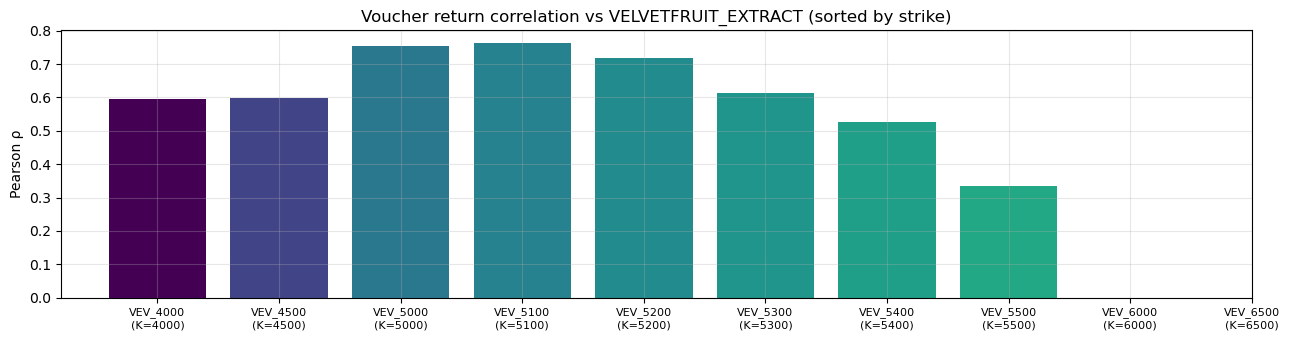

In [53]:
# Voucher returns correlation vs VEV underlying.
vev_corr = corr.loc[VOUCHERS, UNDERLYING].sort_index(key=lambda s: s.map(VOUCHER_STRIKES))
fig, ax = plt.subplots(figsize=(13, 3.5))
ax.bar(range(len(vev_corr)), vev_corr.values,
       color=[VOUCHER_COLOR[v] for v in vev_corr.index])
ax.set_xticks(range(len(vev_corr)))
ax.set_xticklabels([f"{v}\n(K={VOUCHER_STRIKES[v]})" for v in vev_corr.index], fontsize=8)
ax.axhline(0, color="k", lw=0.5)
ax.set_title("Voucher return correlation vs VELVETFRUIT_EXTRACT (sorted by strike)")
ax.set_ylabel("Pearson ρ")
plt.tight_layout(); plt.show()


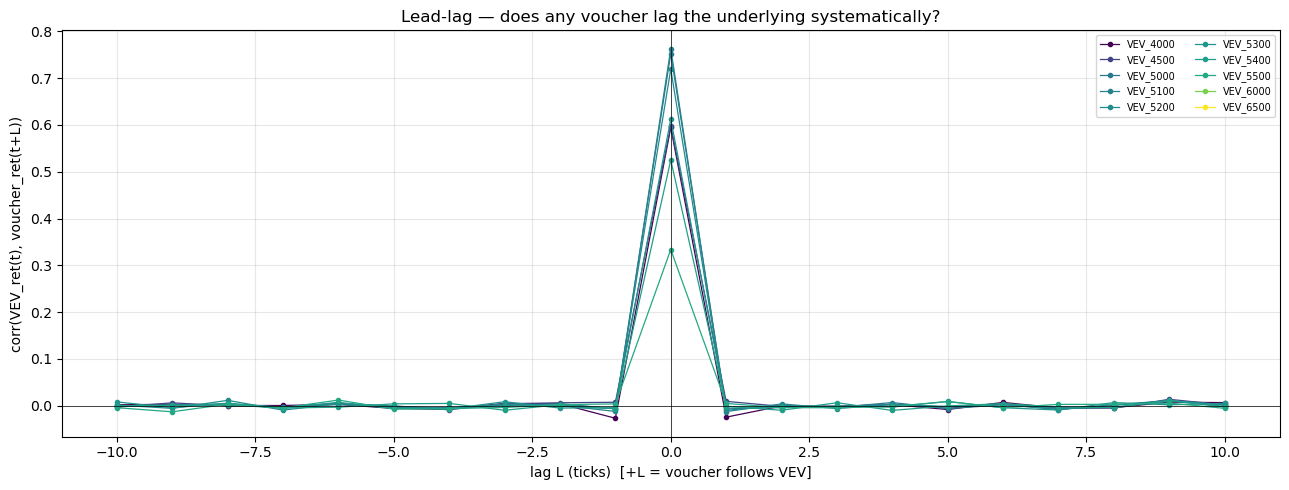

In [54]:
# Lagged correlation: voucher_ret(t) vs VEV_ret(t+L).
LAGS = range(-10, 11)
fig, ax = plt.subplots(figsize=(13, 5))
vev = rets[UNDERLYING].values
for v in VOUCHERS:
    y = rets[v].values
    xs = []
    for L in LAGS:
        if L >= 0:
            a, b = vev[: len(vev) - L], y[L:]
        else:
            a, b = vev[-L:], y[: len(y) + L]
        m = np.isfinite(a) & np.isfinite(b)
        if m.sum() < 10 or a[m].std() == 0 or b[m].std() == 0:
            xs.append(np.nan)
        else:
            xs.append(float(np.corrcoef(a[m], b[m])[0, 1]))
    ax.plot(list(LAGS), xs, "o-", color=VOUCHER_COLOR[v], label=v, ms=3, lw=0.9)
ax.axvline(0, color="k", lw=0.5); ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("lag L (ticks)  [+L = voucher follows VEV]")
ax.set_ylabel("corr(VEV_ret(t), voucher_ret(t+L))")
ax.set_title("Lead-lag — does any voucher lag the underlying systematically?")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()


## 6. Options analytics — the alpha core

This is where Round 3 diverges from the previous rounds. We invert Black-Scholes for each `(voucher, t)` to get the implied-vol surface, then look at smile shape, total variance across days, theta decay, RV-vs-IV, greeks, delta-hedged residuals, and adjacent-strike pair Z-scores.

Because IV inversion is the slowest step, we compute it on a downsampled grid (every `IV_STRIDE` ticks). For most analyses below, the resulting ~10k–35k IV values per voucher are more than enough.

In [55]:
IV_STRIDE = 10  # downsample factor for IV inversion
sub_idx = mids.index[::IV_STRIDE]
S_arr = mids[UNDERLYING].reindex(sub_idx).values
T_arr = tte_years_from_t(sub_idx.values)

iv = pd.DataFrame(index=sub_idx, columns=VOUCHERS, dtype=float)
delta = pd.DataFrame(index=sub_idx, columns=VOUCHERS, dtype=float)
gamma = pd.DataFrame(index=sub_idx, columns=VOUCHERS, dtype=float)
vega  = pd.DataFrame(index=sub_idx, columns=VOUCHERS, dtype=float)

for v, K in VOUCHER_STRIKES.items():
    V = mids[v].reindex(sub_idx).values
    sig = implied_vol_vec(V, S_arr, K, T_arr)
    iv[v] = sig
    d_, g_, ve_ = bs_greeks(S_arr, K, T_arr, np.where(np.isnan(sig), 0.3, sig))
    d_[np.isnan(sig)] = np.nan
    g_[np.isnan(sig)] = np.nan
    ve_[np.isnan(sig)] = np.nan
    delta[v] = d_; gamma[v] = g_; vega[v] = ve_

print("IV inversion success rate per voucher:")
print((iv.notna().mean() * 100).round(1).to_string())


IV inversion success rate per voucher:
VEV_4000      4.3
VEV_4500      4.3
VEV_5000     99.8
VEV_5100    100.0
VEV_5200    100.0
VEV_5300    100.0
VEV_5400    100.0
VEV_5500    100.0
VEV_6000      0.0
VEV_6500      0.0


### 6.1 No-arbitrage sanity

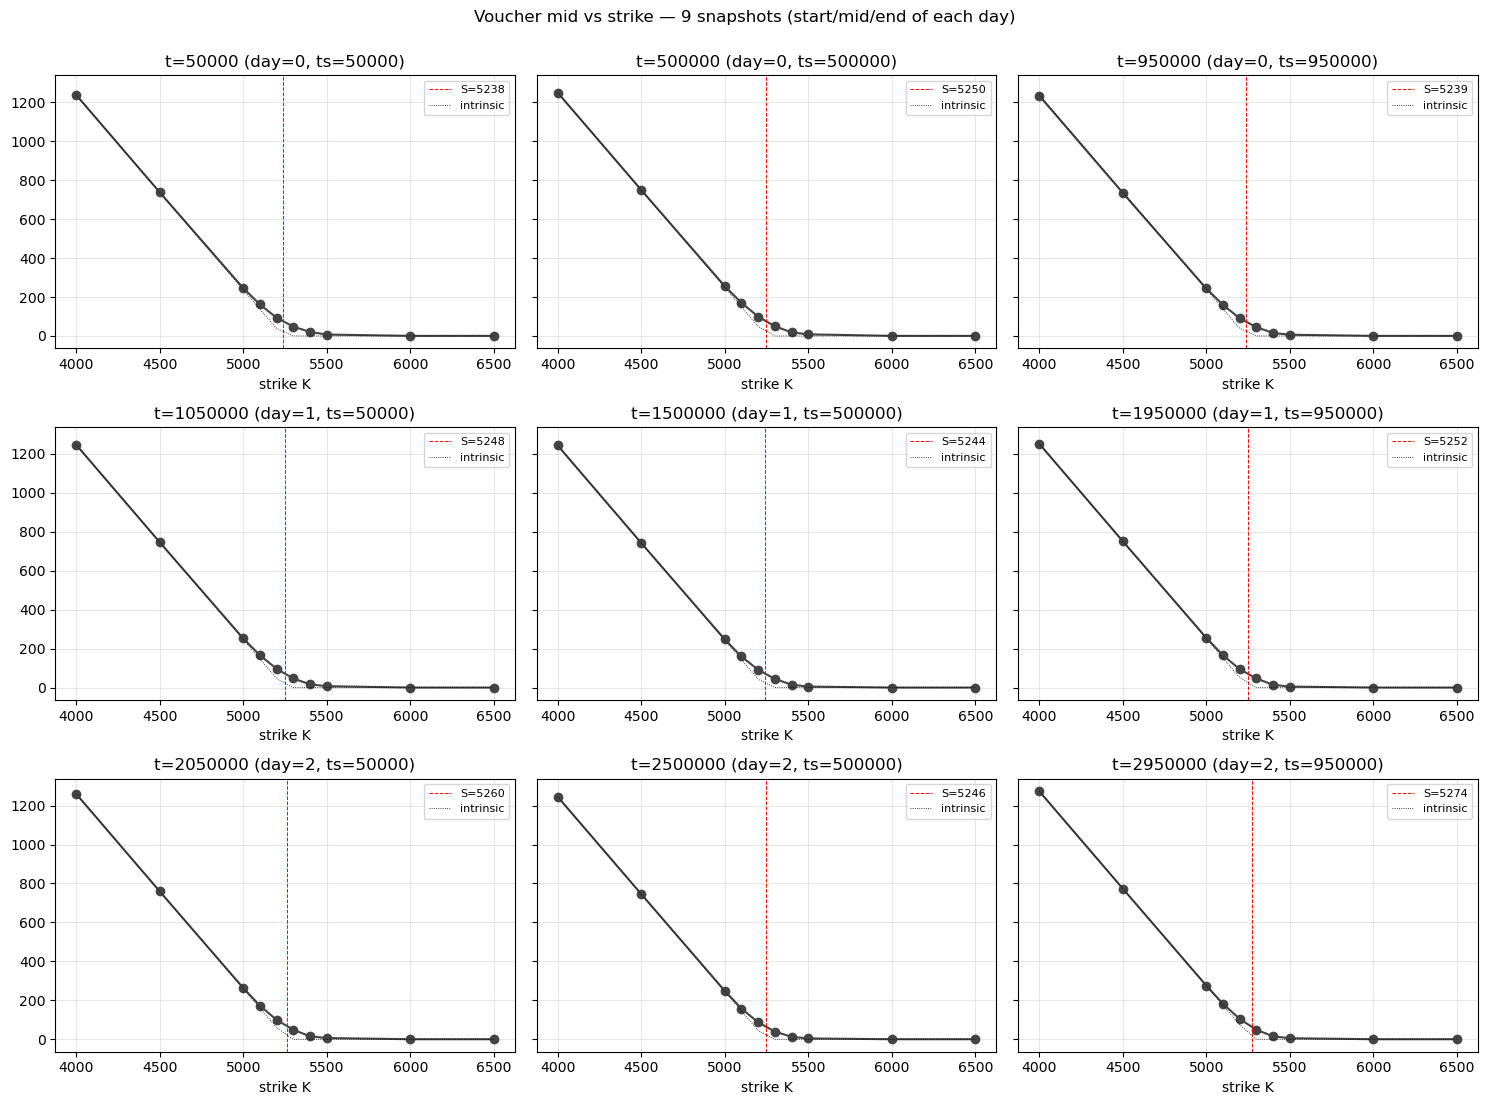

In [56]:
# 9 snapshots: voucher mid vs strike. Calls must be monotone-decreasing in strike.
snap_ts = []
for d in sorted(prices["day"].unique()):
    d_off = (d - min(prices["day"])) * 1_000_000
    for frac in (0.05, 0.50, 0.95):
        snap_ts.append(int(d_off + frac * 1_000_000))

fig, axes = plt.subplots(3, 3, figsize=(15, 11), sharey=True)
for i, t in enumerate(snap_ts):
    ax = axes[i // 3, i % 3]
    nearest = mids.index.get_indexer([t], method="nearest")[0]
    row = mids.iloc[nearest]
    S = row[UNDERLYING]
    Ks = [VOUCHER_STRIKES[v] for v in VOUCHERS]
    Vs = [row[v] for v in VOUCHERS]
    ax.plot(Ks, Vs, "o-", color="#444")
    ax.axvline(S, color="r", lw=0.7, ls="--", label=f"S={S:.0f}")
    intrinsic = [max(S - K, 0) for K in Ks]
    ax.plot(Ks, intrinsic, "k:", lw=0.6, label="intrinsic")
    ax.set_title(f"t={t} (day={t//1_000_000}, ts={t%1_000_000})")
    ax.set_xlabel("strike K"); ax.legend(fontsize=8)
fig.suptitle("Voucher mid vs strike — 9 snapshots (start/mid/end of each day)", y=1.0)
plt.tight_layout(); plt.show()


In [57]:
# Butterfly: C(K-h) - 2 C(K) + C(K+h) >= 0 over adjacent triplets.
viol_rows = []
strikes_sorted = sorted(VOUCHERS, key=lambda x: VOUCHER_STRIKES[x])
for i in range(1, len(strikes_sorted) - 1):
    vL, vM, vR = strikes_sorted[i-1], strikes_sorted[i], strikes_sorted[i+1]
    bf = mids[vL] - 2 * mids[vM] + mids[vR]
    n = bf.notna().sum()
    n_neg = (bf < 0).sum()
    viol_rows.append(dict(
        triplet=f"{vL}/{vM}/{vR}",
        n=n, n_violations=int(n_neg), pct=100 * n_neg / n if n else np.nan,
        min_butterfly=float(bf.min()),
    ))
print("Butterfly violations (calls require non-negative butterfly):")
print(pd.DataFrame(viol_rows).to_string(index=False))

# Intrinsic floor.
intrin_viol = []
for v, K in VOUCHER_STRIKES.items():
    intr = (mids[UNDERLYING] - K).clip(lower=0)
    diff = mids[v] - intr
    n = diff.notna().sum()
    bad = (diff < -0.5).sum()
    intrin_viol.append(dict(
        voucher=v, K=K, n=n, n_below_intrinsic=int(bad),
        pct=100 * bad / n if n else np.nan,
        min_diff=float(diff.min()),
    ))
print("\nIntrinsic-floor violations (mid below max(S-K, 0) - 0.5):")
print(pd.DataFrame(intrin_viol).to_string(index=False))


Butterfly violations (calls require non-negative butterfly):
                   triplet     n  n_violations  pct  min_butterfly
VEV_4000/VEV_4500/VEV_5000 30000             0 0.00            0.0
VEV_4500/VEV_5000/VEV_5100 30000             0 0.00          402.0
VEV_5000/VEV_5100/VEV_5200 30000             0 0.00            9.5
VEV_5100/VEV_5200/VEV_5300 30000             0 0.00           18.0
VEV_5200/VEV_5300/VEV_5400 30000             0 0.00           13.0
VEV_5300/VEV_5400/VEV_5500 30000             0 0.00           12.5
VEV_5400/VEV_5500/VEV_6000 30000             9 0.03           -0.5
VEV_5500/VEV_6000/VEV_6500 30000             0 0.00            2.0

Intrinsic-floor violations (mid below max(S-K, 0) - 0.5):
 voucher    K     n  n_below_intrinsic  pct  min_diff
VEV_4000 4000 30000               1377 4.59      -7.0
VEV_4500 4500 30000               1191 3.97      -6.0
VEV_5000 5000 30000                  0 0.00      -0.5
VEV_5100 5100 30000                  0 0.00       4.5
VEV_520

### 6.2 IV inversion — per-voucher time series

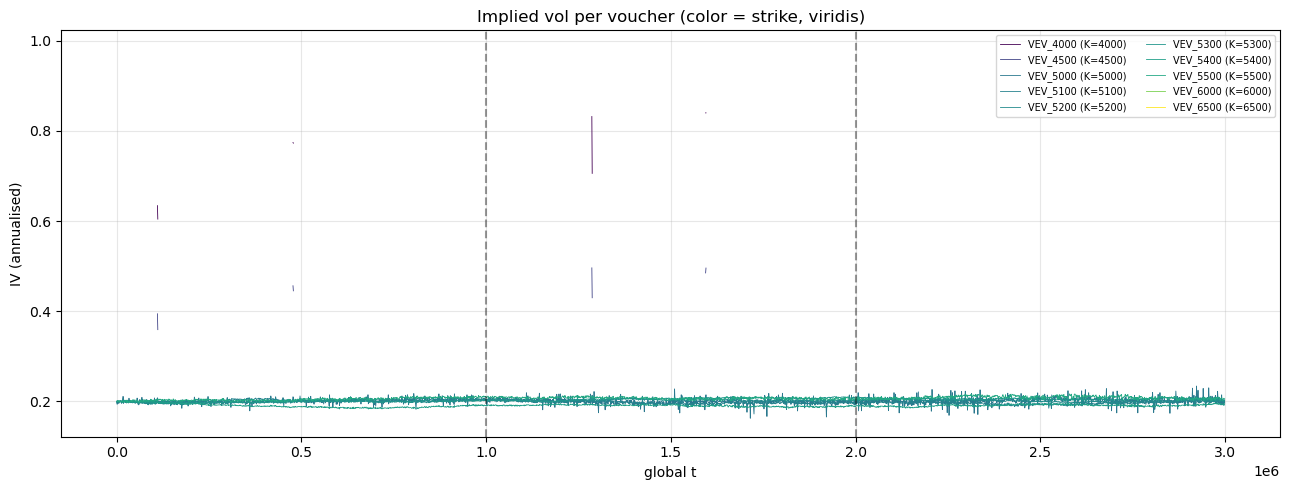

In [58]:
fig, ax = plt.subplots(figsize=(13, 5))
for v in VOUCHERS:
    ax.plot(iv.index, iv[v], color=VOUCHER_COLOR[v], lw=0.6, label=f"{v} (K={VOUCHER_STRIKES[v]})")
for b in day_bounds[1:]:
    ax.axvline(b, color="k", ls="--", alpha=0.4)
ax.set_title("Implied vol per voucher (color = strike, viridis)")
ax.set_ylabel("IV (annualised)"); ax.set_xlabel("global t")
ax.legend(fontsize=7, ncol=2, loc="upper right")
plt.tight_layout(); plt.show()


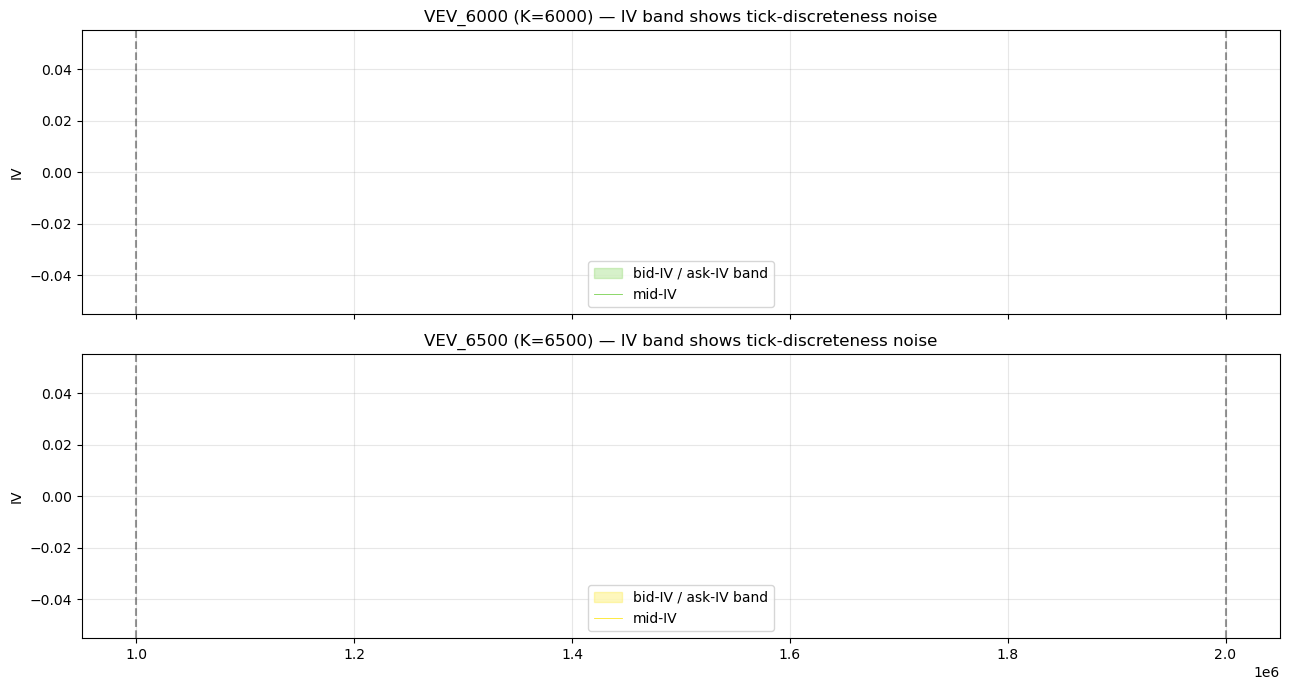

In [59]:
# Bid-IV / ask-IV band for the deep-OTM vouchers (where tick discreteness dominates).
def voucher_bid_ask_iv(voucher_name, K, stride=IV_STRIDE):
    sub = prices[prices["product"] == voucher_name].copy()
    sub = sub[sub["t"].isin(sub_idx)]
    sub_t = sub.set_index("t").reindex(sub_idx)
    bid = sub_t["bid_price_1"].values
    ask = sub_t["ask_price_1"].values
    S = mids[UNDERLYING].reindex(sub_idx).values
    T = tte_years_from_t(sub_idx.values)
    iv_b = implied_vol_vec(bid, S, K, T)
    iv_a = implied_vol_vec(ask, S, K, T)
    return iv_b, iv_a

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
for ax, v in zip(axes, ["VEV_6000", "VEV_6500"]):
    K = VOUCHER_STRIKES[v]
    iv_b, iv_a = voucher_bid_ask_iv(v, K)
    ax.fill_between(sub_idx, iv_b, iv_a, color=VOUCHER_COLOR[v], alpha=0.3, label="bid-IV / ask-IV band")
    ax.plot(iv.index, iv[v], color=VOUCHER_COLOR[v], lw=0.6, label="mid-IV")
    ax.set_title(f"{v} (K={K}) — IV band shows tick-discreteness noise")
    ax.set_ylabel("IV"); ax.legend()
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout(); plt.show()


### 6.3 Smile + total-variance overlay

The headline alpha-finding plot. In raw IV vs log-moneyness, smiles from different days look like different curves because TTE is shrinking. Plotting **total variance** `w(m) = IV²·T` collapses them onto a single shape — anything that doesn't lie on it is mispriced.

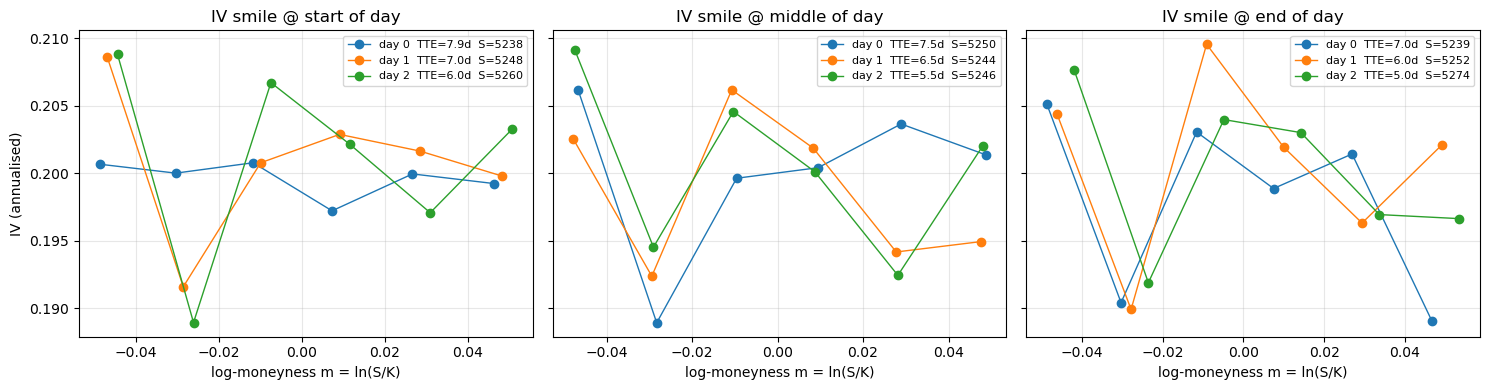

In [60]:
def smile_at(t_target):
    nearest = mids.index.get_indexer([t_target], method="nearest")[0]
    t_actual = mids.index[nearest]
    iv_idx_pos = iv.index.get_indexer([t_actual], method="nearest")[0]
    row_iv = iv.iloc[iv_idx_pos]
    S = mids[UNDERLYING].iloc[nearest]
    K = np.array([VOUCHER_STRIKES[v] for v in VOUCHERS])
    sigma = row_iv[VOUCHERS].values.astype(float)
    m = np.log(S / K)
    T = tte_years_from_t([t_actual])[0]
    return t_actual, S, m, sigma, T

# IV smile snapshots (start / mid / end of each day).
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, frac, label in zip(axes, (0.05, 0.50, 0.95), ("start", "middle", "end")):
    for d in sorted(prices["day"].unique()):
        d_off = (d - min(prices["day"])) * 1_000_000
        t_target = int(d_off + frac * 1_000_000)
        t_actual, S, m, sigma, T = smile_at(t_target)
        order_m = np.argsort(m)
        ax.plot(m[order_m], sigma[order_m], "o-",
                label=f"day {d}  TTE={T*DAYS_PER_YEAR:.1f}d  S={S:.0f}", lw=1)
    ax.set_title(f"IV smile @ {label} of day")
    ax.set_xlabel("log-moneyness m = ln(S/K)")
    ax.legend(fontsize=8)
axes[0].set_ylabel("IV (annualised)")
plt.tight_layout(); plt.show()


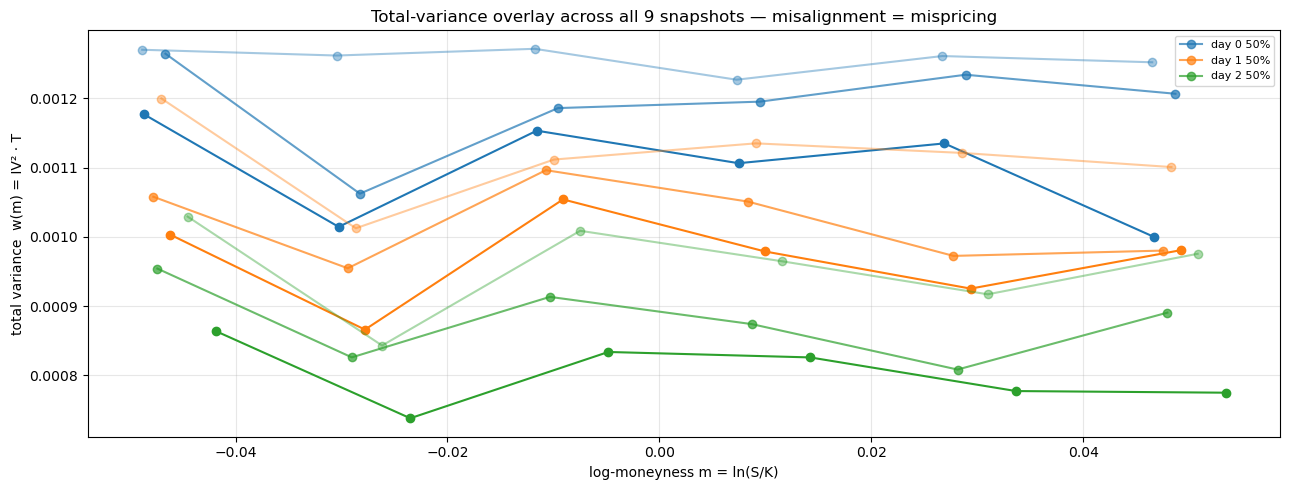

In [61]:
# Total-variance overlay: w(m) = IV^2 * T. Should align across days.
fig, ax = plt.subplots(figsize=(13, 5))
for d in sorted(prices["day"].unique()):
    d_off = (d - min(prices["day"])) * 1_000_000
    for frac, alpha_v in zip((0.05, 0.50, 0.95), (0.4, 0.7, 1.0)):
        t_actual, S, m, sigma, T = smile_at(int(d_off + frac * 1_000_000))
        w = sigma * sigma * T
        order_m = np.argsort(m)
        ax.plot(m[order_m], w[order_m], "o-", alpha=alpha_v,
                color=cm.tab10(d % 10), label=f"day {d} {int(frac*100)}%" if frac == 0.5 else None)
ax.set_xlabel("log-moneyness m = ln(S/K)")
ax.set_ylabel("total variance  w(m) = IV² · T")
ax.set_title("Total-variance overlay across all 9 snapshots — misalignment = mispricing")
ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


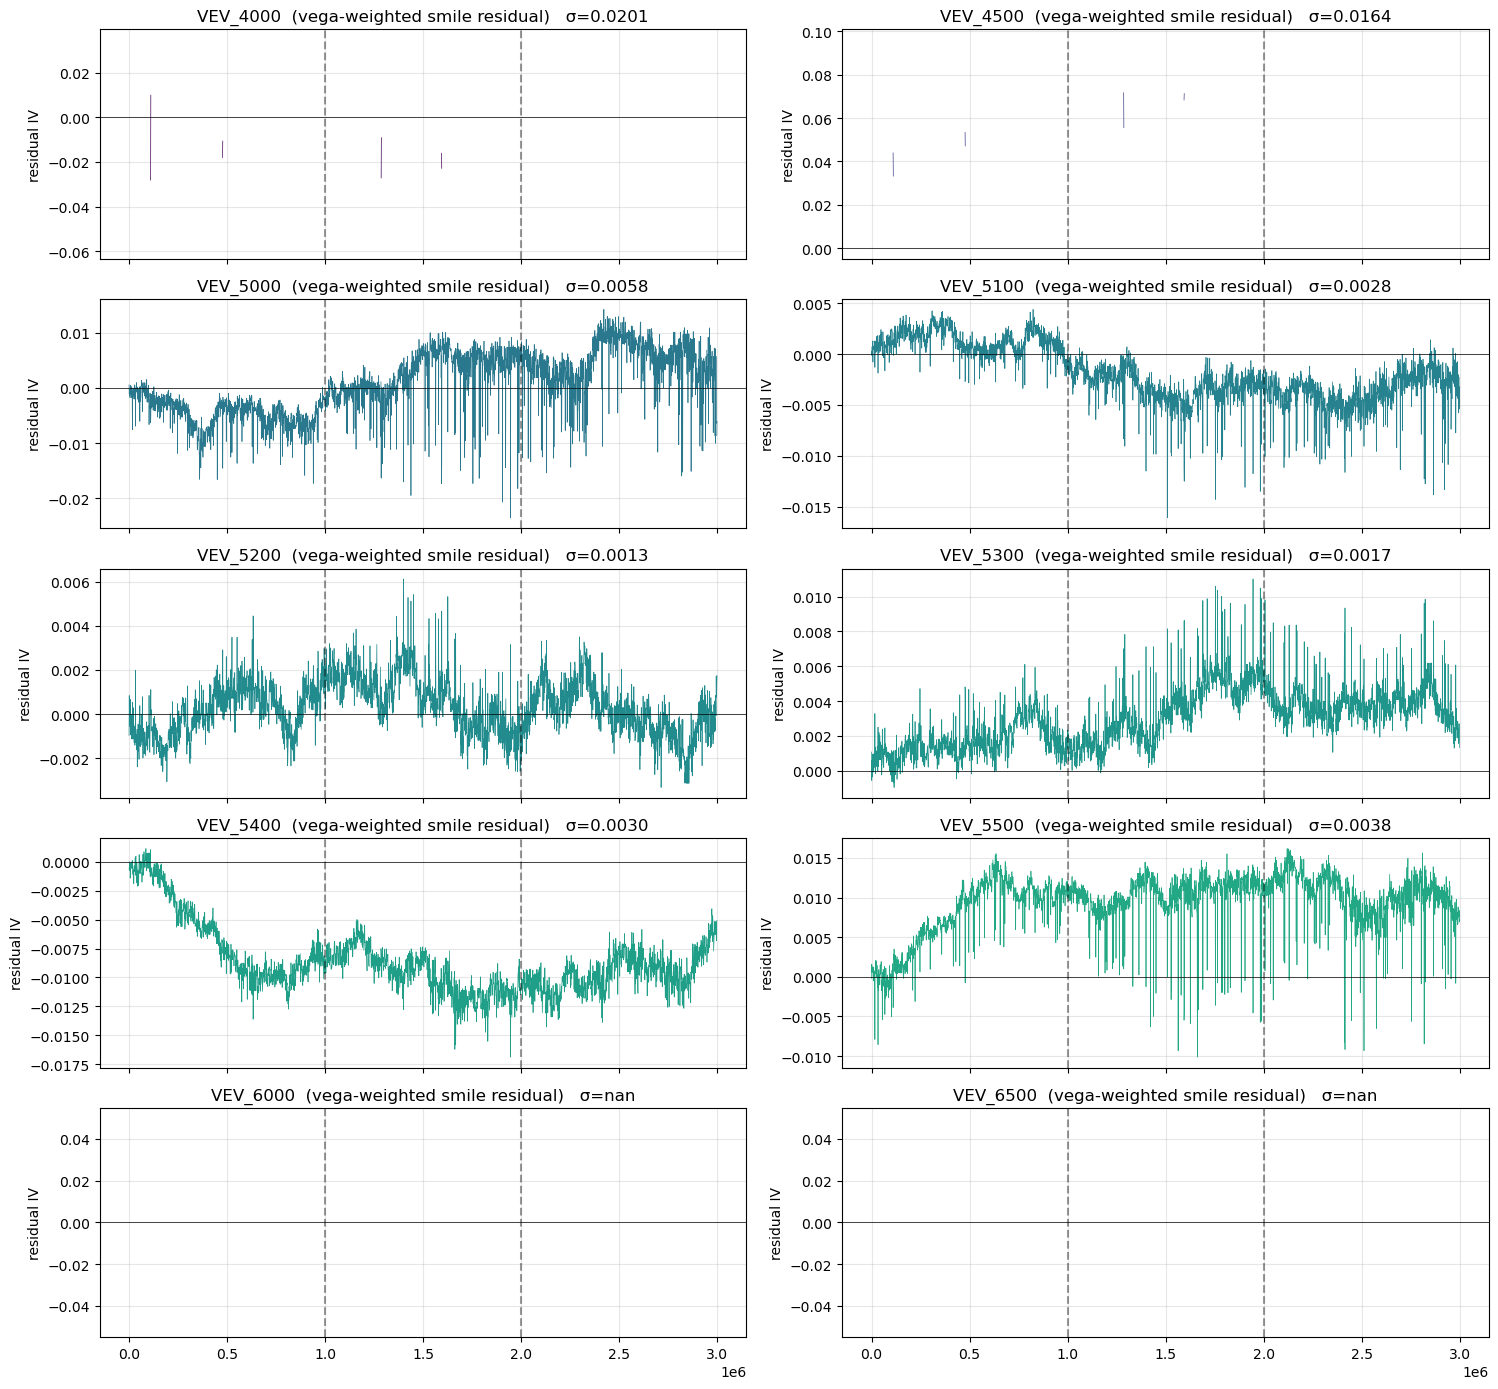


Residual mean & std per voucher (smile-fit alpha candidates):
             mean      std   count
VEV_4000 -0.01050  0.02006   128.0
VEV_4500  0.05729  0.01640   128.0
VEV_5000  0.00074  0.00581  2995.0
VEV_5100 -0.00188  0.00284  3000.0
VEV_5200  0.00029  0.00126  3000.0
VEV_5300  0.00299  0.00169  3000.0
VEV_5400 -0.00860  0.00296  3000.0
VEV_5500  0.00925  0.00384  3000.0
VEV_6000      NaN      NaN     0.0
VEV_6500      NaN      NaN     0.0


In [62]:
# Per-tick parabolic fit IV ≈ a + b·m + c·m^2 across the panel of available IVs.
# Vega-weighted residuals per voucher.
S_full = mids[UNDERLYING].reindex(sub_idx).values
K_arr = np.array([VOUCHER_STRIKES[v] for v in VOUCHERS])  # (10,)
m_full = np.log(S_full[:, None] / K_arr[None, :])  # (T, 10)
iv_mat = iv[VOUCHERS].values  # (T, 10)
vega_mat = vega[VOUCHERS].values

residuals = np.full_like(iv_mat, np.nan)
for i in range(iv_mat.shape[0]):
    y = iv_mat[i]
    x = m_full[i]
    w = vega_mat[i]
    msk = np.isfinite(y) & np.isfinite(x) & np.isfinite(w) & (w > 0)
    if msk.sum() < 4:
        continue
    X = np.c_[np.ones(msk.sum()), x[msk], x[msk]**2]
    W = np.diag(w[msk])
    try:
        beta, *_ = np.linalg.lstsq(W @ X, W @ y[msk], rcond=None)
        y_hat = X @ beta
        residuals[i, msk] = y[msk] - y_hat
    except np.linalg.LinAlgError:
        continue

residuals_df = pd.DataFrame(residuals, index=sub_idx, columns=VOUCHERS)

# 10-panel grid.
fig, axes = plt.subplots(5, 2, figsize=(15, 14), sharex=True)
for i, v in enumerate(VOUCHERS):
    ax = axes[i // 2, i % 2]
    ax.plot(residuals_df.index, residuals_df[v], color=VOUCHER_COLOR[v], lw=0.5)
    ax.axhline(0, color="k", lw=0.5)
    rstd = residuals_df[v].std()
    ax.set_title(f"{v}  (vega-weighted smile residual)   σ={rstd:.4f}")
    ax.set_ylabel("residual IV")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout(); plt.show()

print("\nResidual mean & std per voucher (smile-fit alpha candidates):")
print(residuals_df.agg(["mean", "std", "count"]).T.round(5))


### 6.3.5 Price-space residuals + 1-lag ACF (the 1st-place 2024 IV-scalping signal)

Last year's winners' core trade: convert the smile residual `v_t − v̂_t` to **price** space via Black-Scholes, then trade the deviation. Mean reversion is much cleaner in price than in IV. Validation: 1-lag negative autocorrelation on the price residual confirms exploitable scalping.

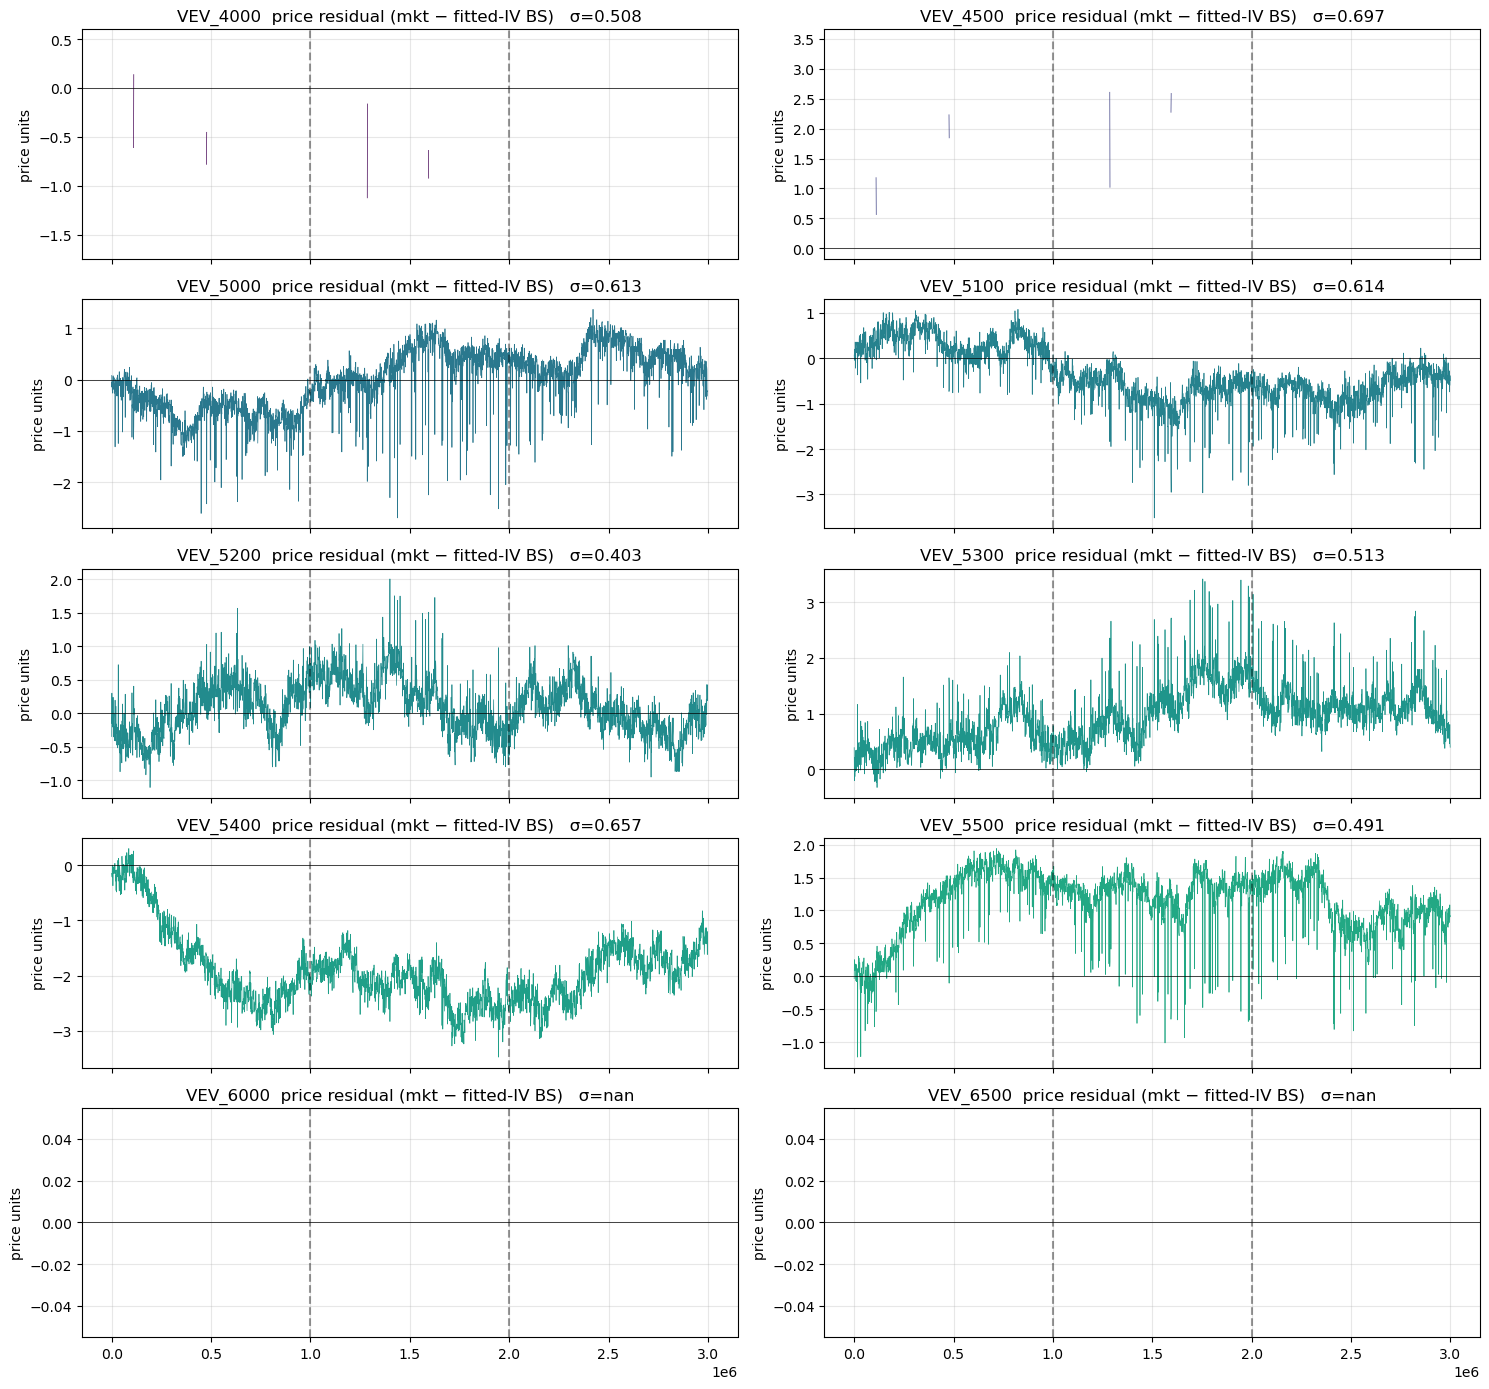

In [63]:
# Price-space residual: market mid - BS price using fitted-smile IV v̂(m).
fitted_iv = iv_mat - residuals  # v̂_t at each (t, voucher); residuals are vega-weighted
# To get price: use S, K, T with v̂(m).
T_full = tte_years_from_t(sub_idx.values)[:, None] * np.ones_like(K_arr)[None, :]
S_full_2d = np.broadcast_to(S_full[:, None], iv_mat.shape)
K_full = np.broadcast_to(K_arr[None, :], iv_mat.shape)

with np.errstate(invalid="ignore", divide="ignore"):
    bs_fair = bs_call_price(S_full_2d, K_full, T_full, np.where(np.isnan(fitted_iv), 0.3, fitted_iv))
bs_fair = np.where(np.isnan(fitted_iv), np.nan, bs_fair)
mkt_mid = mids[VOUCHERS].reindex(sub_idx).values
price_resid = mkt_mid - bs_fair

price_resid_df = pd.DataFrame(price_resid, index=sub_idx, columns=VOUCHERS)

fig, axes = plt.subplots(5, 2, figsize=(15, 14), sharex=True)
for i, v in enumerate(VOUCHERS):
    ax = axes[i // 2, i % 2]
    ax.plot(price_resid_df.index, price_resid_df[v], color=VOUCHER_COLOR[v], lw=0.5)
    ax.axhline(0, color="k", lw=0.5)
    rstd = price_resid_df[v].std()
    ax.set_title(f"{v}  price residual (mkt − fitted-IV BS)   σ={rstd:.3f}")
    ax.set_ylabel("price units")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout(); plt.show()


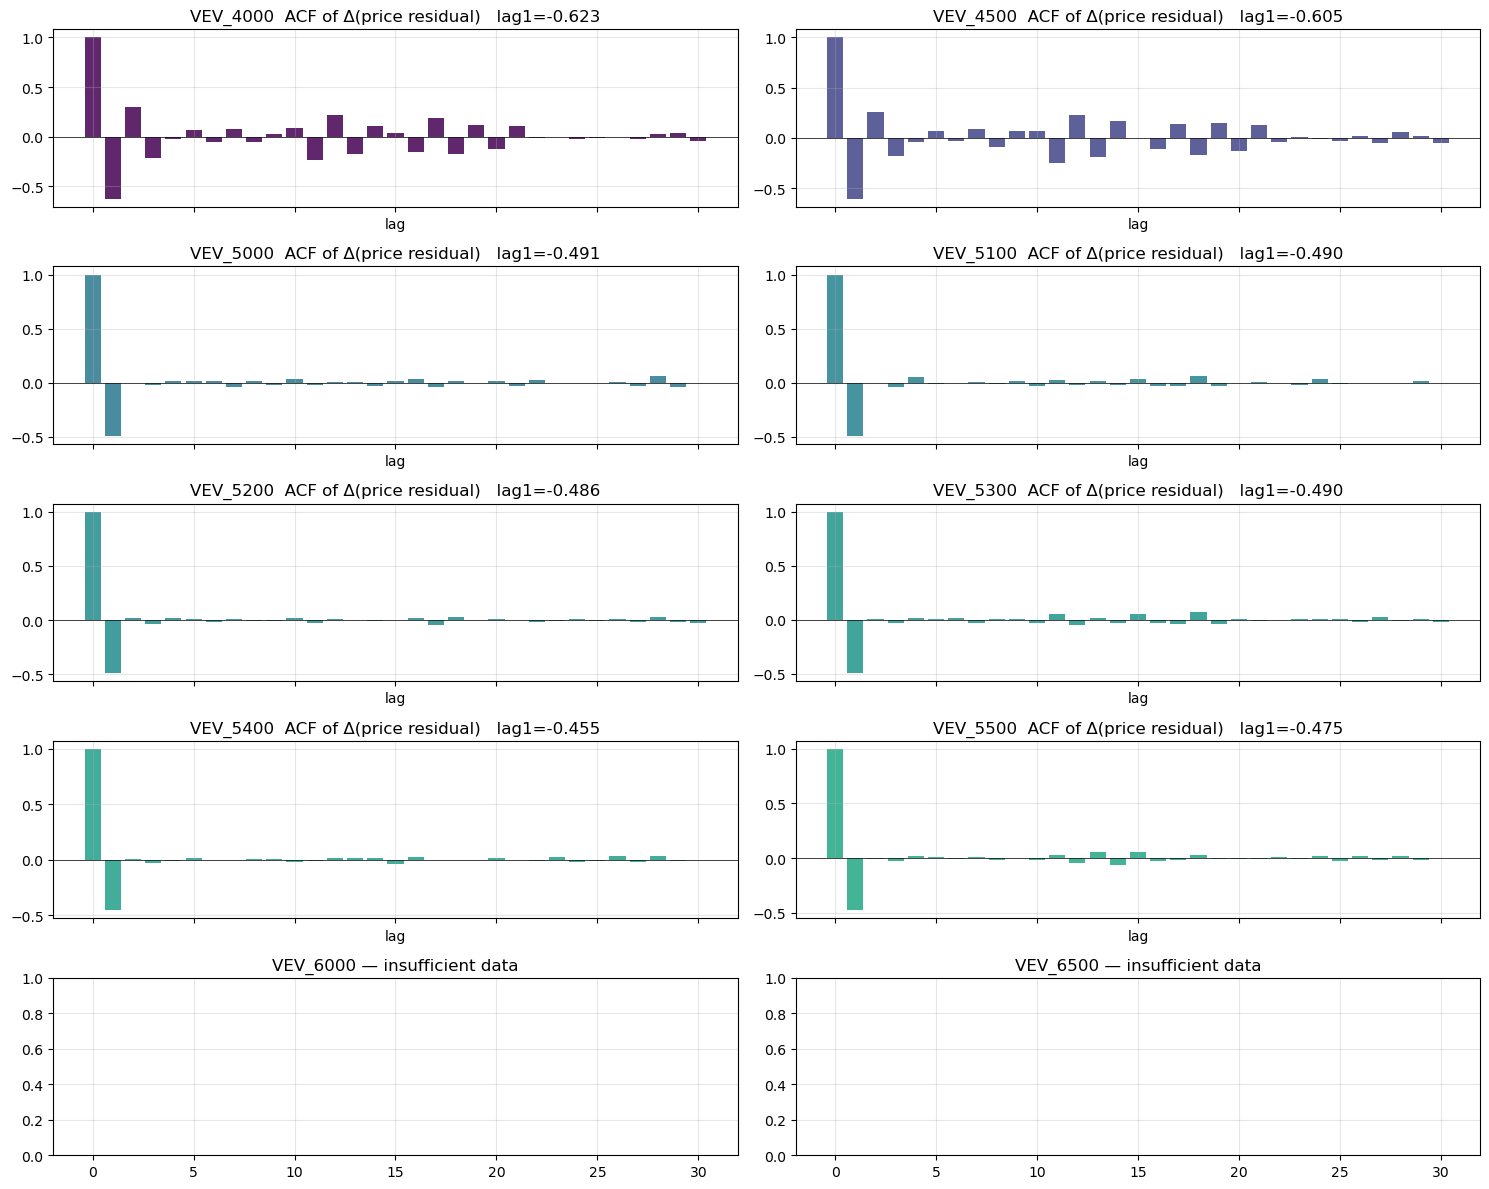


Lag-1 autocorrelation of Δ(price residual) — strongly negative = scalpable:
  VEV_4000    ACF(1) = -0.623
  VEV_4500    ACF(1) = -0.605
  VEV_5000    ACF(1) = -0.491
  VEV_5300    ACF(1) = -0.490
  VEV_5100    ACF(1) = -0.490
  VEV_5200    ACF(1) = -0.486
  VEV_5500    ACF(1) = -0.475
  VEV_5400    ACF(1) = -0.455


In [64]:
# ACF of price residuals — winner's validation: lag 1 should be NEGATIVE.
# Strong negative ACF(1) on the changes => exploitable mean reversion in price.
LAGS = 30
fig, axes = plt.subplots(5, 2, figsize=(15, 12), sharex=True)
acf_lag1 = []
for i, v in enumerate(VOUCHERS):
    ax = axes[i // 2, i % 2]
    series = price_resid_df[v].dropna().diff().dropna().values
    if len(series) < LAGS + 10:
        ax.set_title(f"{v} — insufficient data"); continue
    a = acf(series, LAGS)
    ax.bar(range(LAGS + 1), a, color=VOUCHER_COLOR[v], alpha=0.85)
    ax.axhline(0, color="k", lw=0.5)
    ax.set_title(f"{v}  ACF of Δ(price residual)   lag1={a[1]:+.3f}")
    ax.set_xlabel("lag")
    acf_lag1.append((v, float(a[1])))
plt.tight_layout(); plt.show()

print("\nLag-1 autocorrelation of Δ(price residual) — strongly negative = scalpable:")
for v, x in sorted(acf_lag1, key=lambda kv: kv[1]):
    print(f"  {v:<10}  ACF(1) = {x:+.3f}")


### 6.4 ATM IV + theta decay

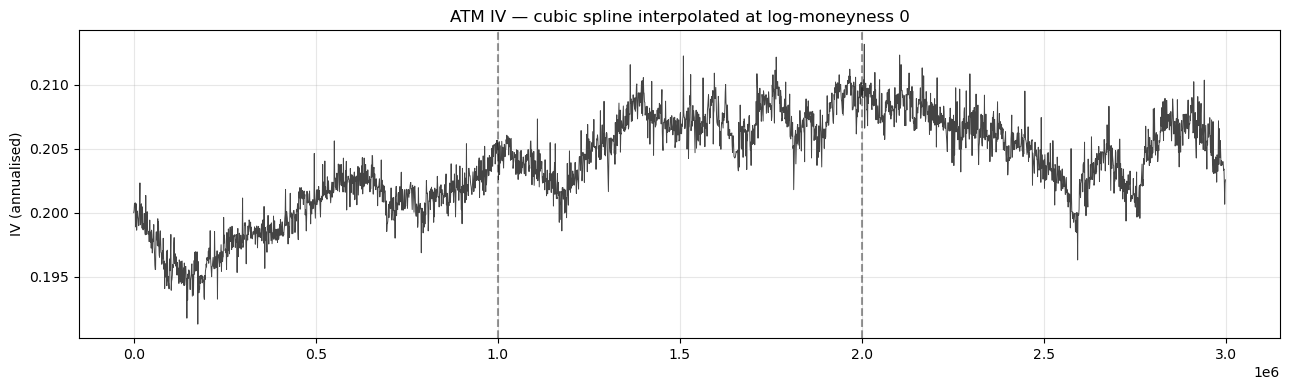

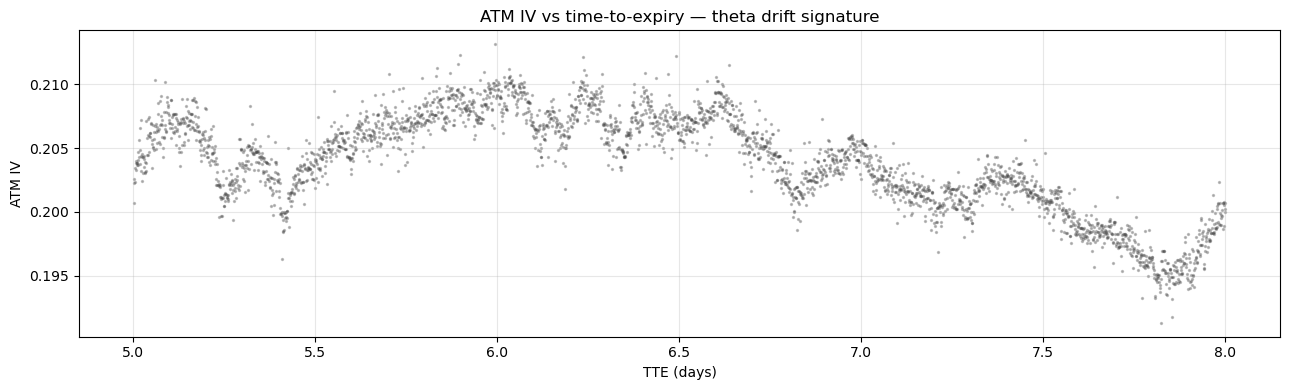

In [65]:
# Cubic-spline interpolate IV at m=0 per timestamp.
atm_iv = np.full(len(sub_idx), np.nan)
for i in range(iv_mat.shape[0]):
    y = iv_mat[i]; x = m_full[i]
    msk = np.isfinite(y) & np.isfinite(x)
    if msk.sum() < 3:
        continue
    xs, ys = x[msk], y[msk]
    order = np.argsort(xs); xs, ys = xs[order], ys[order]
    # Need m=0 inside range or it's an extrapolation.
    if xs.min() <= 0 <= xs.max():
        try:
            cs = CubicSpline(xs, ys)
            atm_iv[i] = float(cs(0.0))
        except Exception:
            pass

atm_iv = pd.Series(atm_iv, index=sub_idx, name="ATM_IV")

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(atm_iv.index, atm_iv.values, color="#444", lw=0.7)
for b in day_bounds[1:]:
    ax.axvline(b, color="k", ls="--", alpha=0.4)
ax.set_title("ATM IV — cubic spline interpolated at log-moneyness 0")
ax.set_ylabel("IV (annualised)")
plt.tight_layout(); plt.show()

# ATM IV vs TTE_days. With theta decay, expect drift.
TTE_d = (EXPIRY_DAYS_AT_DAY0 - sub_idx.values / 1_000_000.0)
fig, ax = plt.subplots(figsize=(13, 4))
ax.scatter(TTE_d, atm_iv.values, s=2, alpha=0.3, color="#444")
ax.set_xlabel("TTE (days)"); ax.set_ylabel("ATM IV")
ax.set_title("ATM IV vs time-to-expiry — theta drift signature")
plt.tight_layout(); plt.show()


### 6.5 Realized vs Implied vol

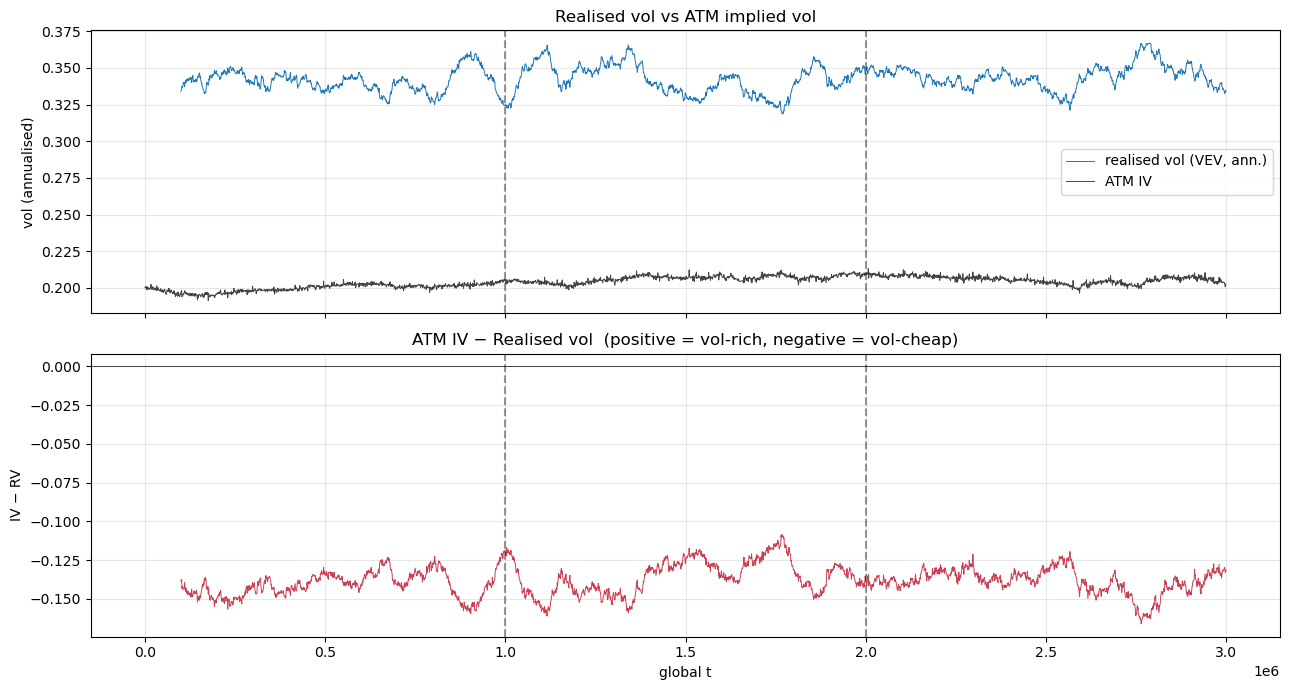

In [66]:
# Align rolling RV onto the IV grid.
rv_on_iv = rv_ann.reindex(sub_idx, method="ffill")
spread = atm_iv - rv_on_iv

fig, ax = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax[0].plot(rv_on_iv.index, rv_on_iv.values, color=SPOT_COLOR[UNDERLYING], lw=0.7, label="realised vol (VEV, ann.)")
ax[0].plot(atm_iv.index, atm_iv.values, color="#444", lw=0.7, label="ATM IV")
ax[0].set_ylabel("vol (annualised)")
ax[0].legend(); ax[0].set_title("Realised vol vs ATM implied vol")
ax[1].plot(spread.index, spread.values, color="#cb4154", lw=0.7)
ax[1].axhline(0, color="k", lw=0.5)
ax[1].set_title("ATM IV − Realised vol  (positive = vol-rich, negative = vol-cheap)")
ax[1].set_ylabel("IV − RV"); ax[1].set_xlabel("global t")
for b in day_bounds[1:]:
    for a in ax:
        a.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout(); plt.show()


### 6.6 Greeks

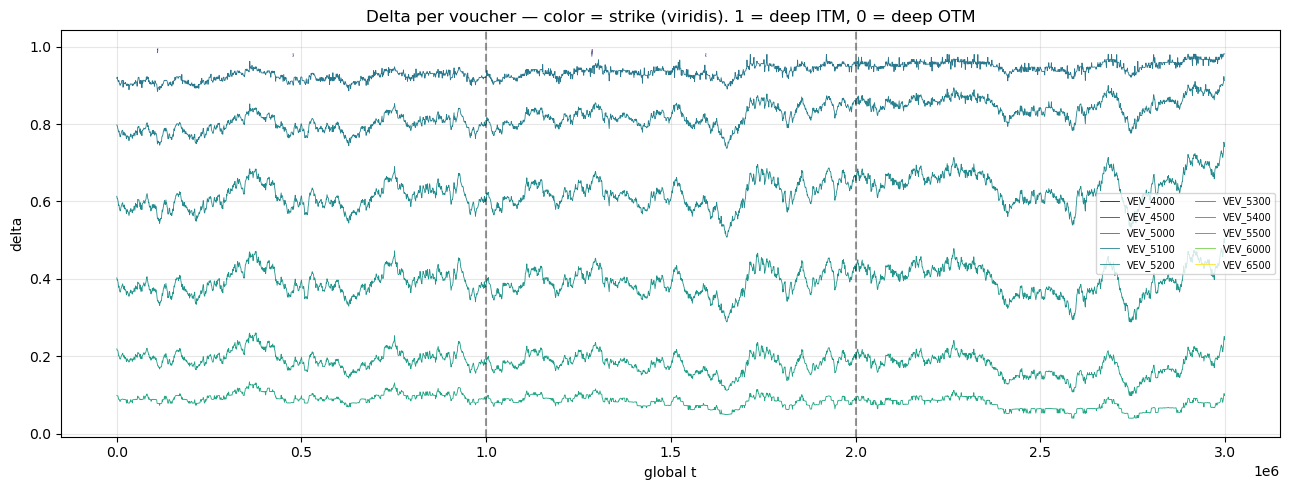

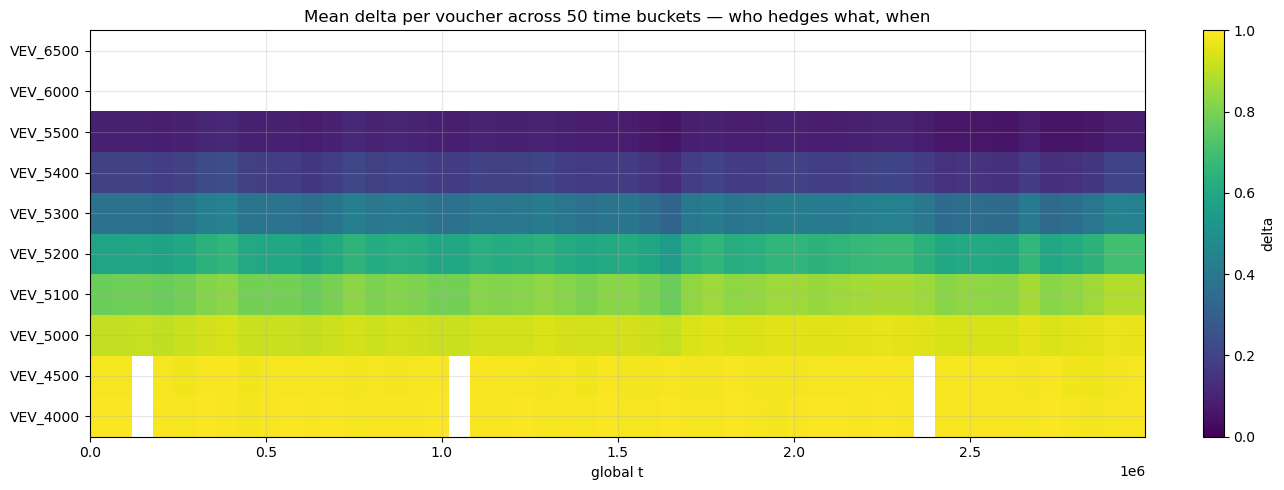

In [67]:
# Delta time series, all vouchers.
fig, ax = plt.subplots(figsize=(13, 5))
for v in VOUCHERS:
    ax.plot(delta.index, delta[v], color=VOUCHER_COLOR[v], lw=0.6, label=v)
ax.set_title("Delta per voucher — color = strike (viridis). 1 = deep ITM, 0 = deep OTM")
ax.set_ylabel("delta"); ax.set_xlabel("global t")
ax.legend(fontsize=7, ncol=2)
for b in day_bounds[1:]:
    ax.axvline(b, color="k", ls="--", alpha=0.4)
plt.tight_layout(); plt.show()

# Delta heatmap: rows = voucher (sorted), cols = time bins.
N_BUCKETS = 50
t_min, t_max = float(delta.index.min()), float(delta.index.max())
edges = np.linspace(t_min, t_max, N_BUCKETS + 1)
centers = 0.5 * (edges[:-1] + edges[1:])
buckets = np.searchsorted(edges, delta.index.values, side="right") - 1
buckets = np.clip(buckets, 0, N_BUCKETS - 1)

heat = np.full((len(VOUCHERS), N_BUCKETS), np.nan)
for j, v in enumerate(VOUCHERS):
    series = delta[v].values
    df_t = pd.DataFrame({"b": buckets, "d": series}).dropna()
    grouped = df_t.groupby("b")["d"].mean()
    for k, val in grouped.items():
        heat[j, k] = val

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(heat, aspect="auto", origin="lower", cmap="viridis", vmin=0, vmax=1,
               extent=[t_min, t_max, -0.5, len(VOUCHERS) - 0.5])
ax.set_yticks(range(len(VOUCHERS)))
ax.set_yticklabels(VOUCHERS)
ax.set_xlabel("global t")
ax.set_title("Mean delta per voucher across 50 time buckets — who hedges what, when")
plt.colorbar(im, ax=ax, fraction=0.04, label="delta")
plt.tight_layout(); plt.show()


### 6.7 Delta-hedged residuals

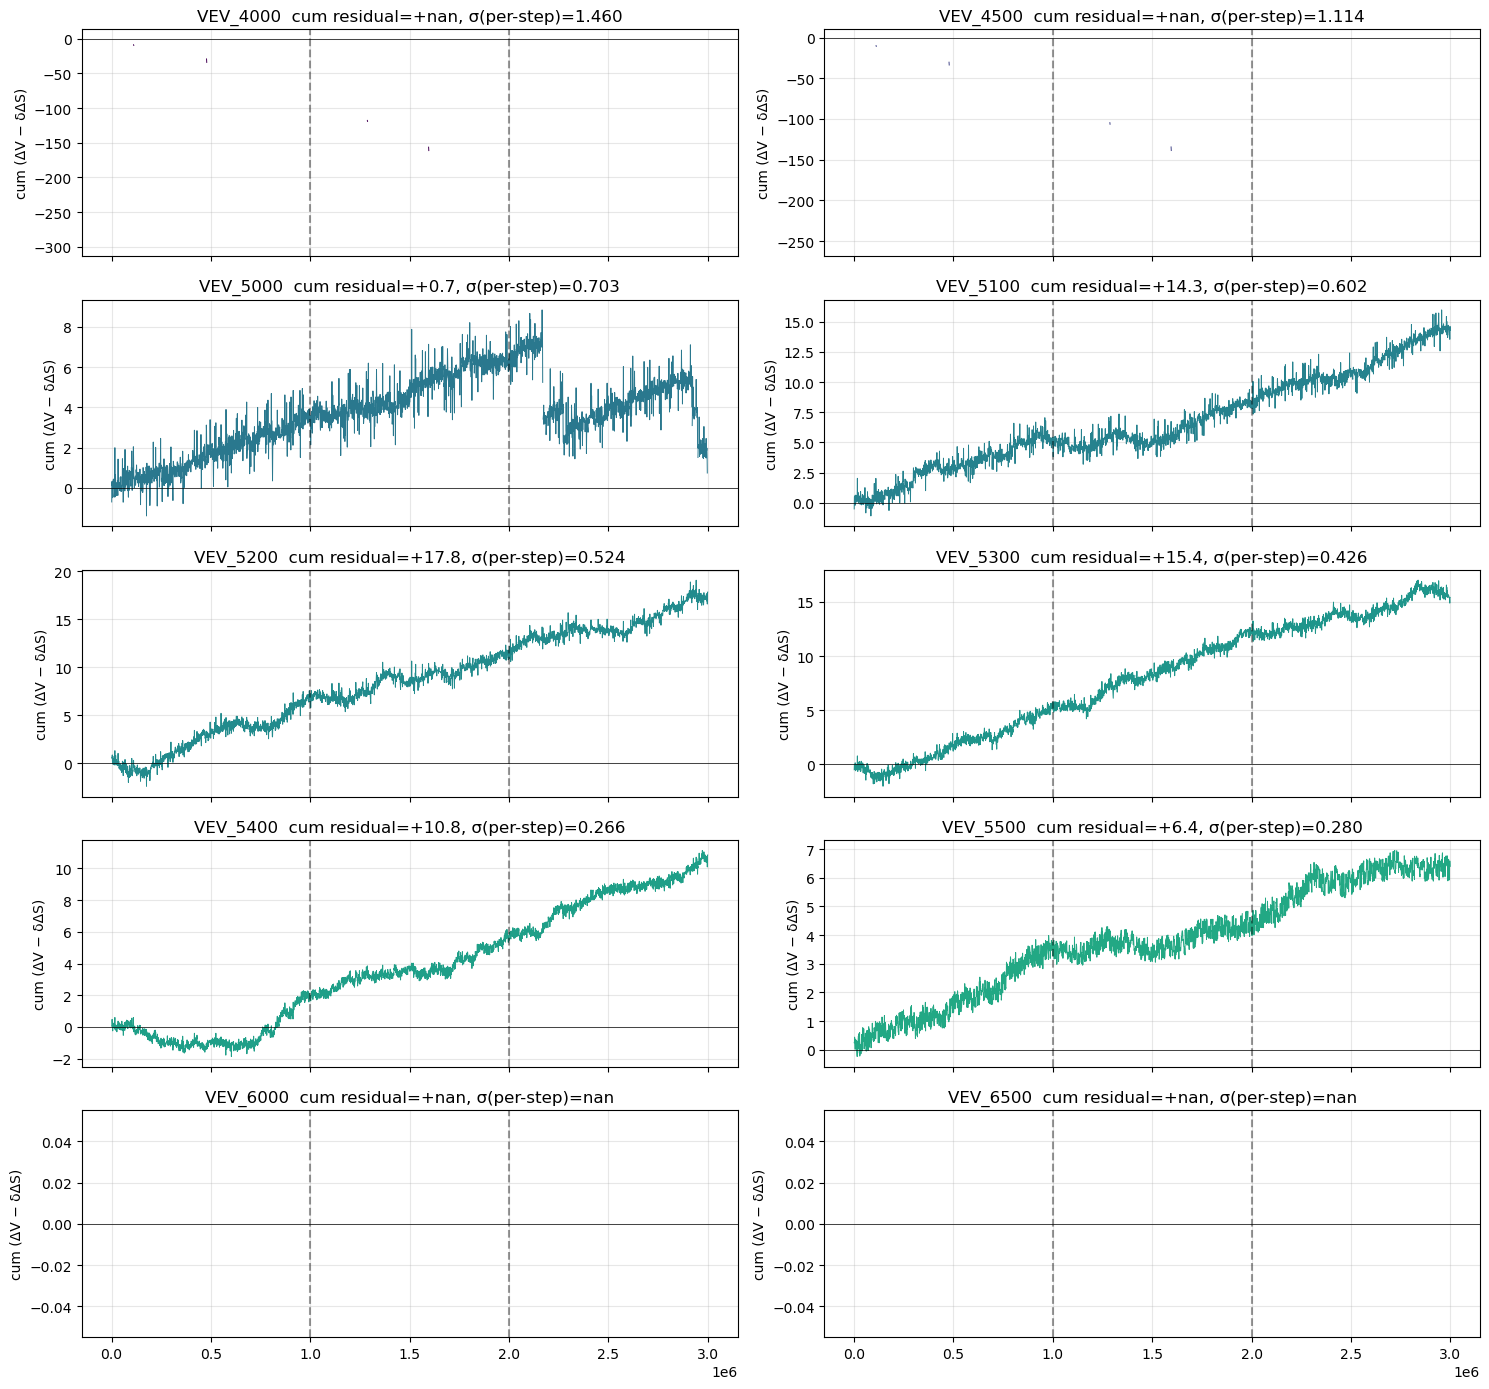


Delta-hedge residual summary (positive cum residual = voucher rich vs spot hedge):
 voucher    K  cum_residual  step_std
VEV_4000 4000           NaN  1.460111
VEV_4500 4500           NaN  1.114038
VEV_5000 5000      0.661945  0.703001
VEV_5100 5100     14.267996  0.602257
VEV_5200 5200     17.844016  0.524104
VEV_5300 5300     15.405404  0.425724
VEV_5400 5400     10.845205  0.266413
VEV_5500 5500      6.398598  0.280261
VEV_6000 6000           NaN       NaN
VEV_6500 6500           NaN       NaN


In [68]:
# residual_t = ΔV_t - δ_{t-1} · ΔS_t. Cumulative drift = mispricing alpha.
S_series = mids[UNDERLYING].reindex(sub_idx)
dS = S_series.diff()

fig, axes = plt.subplots(5, 2, figsize=(15, 14), sharex=True)
hedge_summary = []
for i, v in enumerate(VOUCHERS):
    ax = axes[i // 2, i % 2]
    V_series = mids[v].reindex(sub_idx)
    dV = V_series.diff()
    delta_lag = delta[v].shift(1)
    resid = dV - delta_lag * dS
    cum = resid.cumsum()
    ax.plot(cum.index, cum.values, color=VOUCHER_COLOR[v], lw=0.7)
    ax.axhline(0, color="k", lw=0.5)
    final = cum.iloc[-1] if len(cum.dropna()) else np.nan
    rstd = resid.std()
    ax.set_title(f"{v}  cum residual={final:+.1f}, σ(per-step)={rstd:.3f}")
    ax.set_ylabel("cum (ΔV − δΔS)")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
    hedge_summary.append(dict(voucher=v, K=VOUCHER_STRIKES[v],
                              cum_residual=float(final) if pd.notna(final) else np.nan,
                              step_std=float(rstd)))
plt.tight_layout(); plt.show()

print("\nDelta-hedge residual summary (positive cum residual = voucher rich vs spot hedge):")
print(pd.DataFrame(hedge_summary).to_string(index=False))


### 6.8 Adjacent-strike IV pair Z-scores  +  vertical-spread arbitrage check

Two angles on adjacent-strike pairs:

1. **IV spread Z-score** — when an adjacent-strike IV spread blows out, mean-revert it. Heavy in the 1st-place playbook.
2. **Vertical-spread arbitrage** (2nd place): a long call spread `C(K1) − C(K2)` with `K1 < K2` cannot exceed `K2 − K1` (and cannot be negative). Free money when violated.

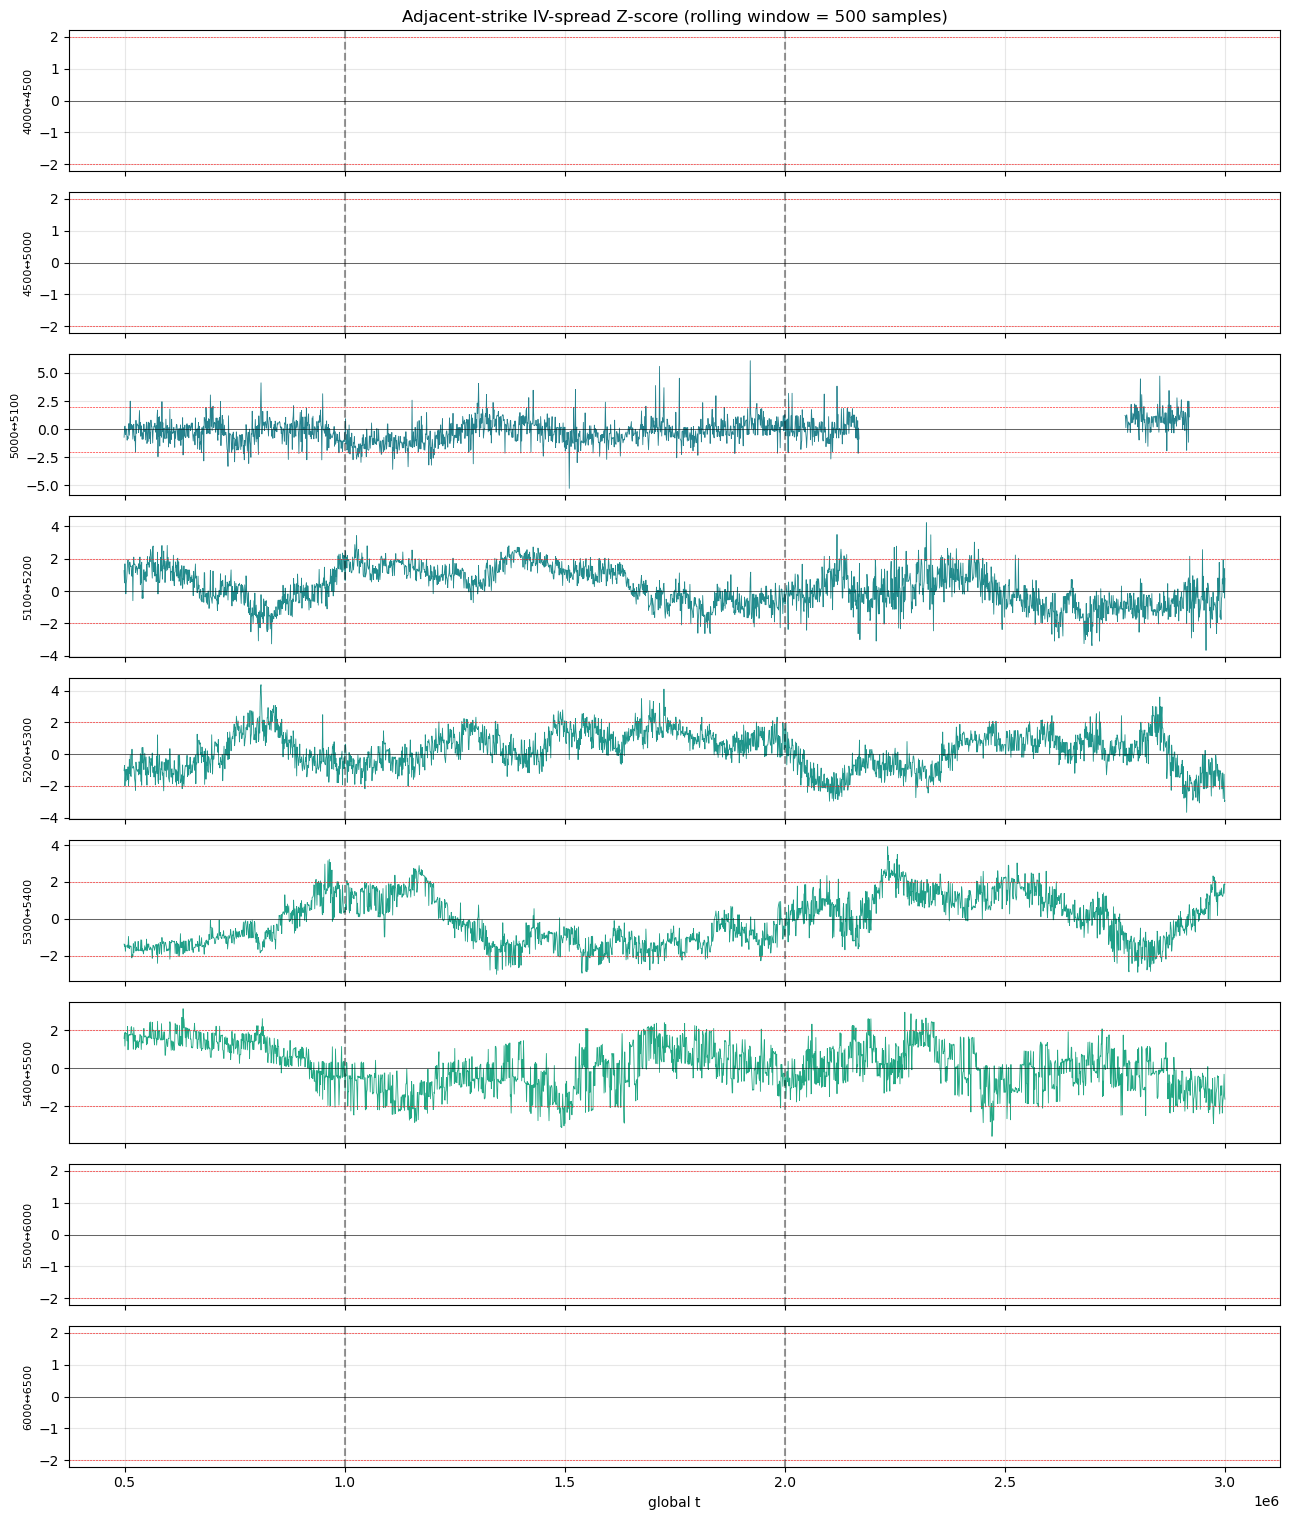

In [69]:
ROLL = 5000 // IV_STRIDE  # ~5000 ticks of underlying-time
sorted_v = sorted(VOUCHERS, key=lambda v: VOUCHER_STRIKES[v])
pairs = list(zip(sorted_v[:-1], sorted_v[1:]))

fig, axes = plt.subplots(len(pairs), 1, figsize=(13, 1.7 * len(pairs)), sharex=True)
for ax, (vL, vR) in zip(axes, pairs):
    diff = iv[vR] - iv[vL]
    mu = diff.rolling(ROLL).mean()
    sd = diff.rolling(ROLL).std()
    z = (diff - mu) / sd.replace(0, np.nan)
    ax.plot(z.index, z.values, color=VOUCHER_COLOR[vR], lw=0.6)
    ax.axhline(0, color="k", lw=0.4)
    ax.axhline(2, color="r", lw=0.4, ls="--")
    ax.axhline(-2, color="r", lw=0.4, ls="--")
    ax.set_ylabel(f"{vL.split('_')[1]}↔{vR.split('_')[1]}", fontsize=8)
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
axes[0].set_title(f"Adjacent-strike IV-spread Z-score (rolling window = {ROLL} samples)")
axes[-1].set_xlabel("global t")
plt.tight_layout(); plt.show()


Vertical-spread arbitrage scan (price spread vs strike spread):
             pair  K_low  K_high  max_allowed     n  n_negative  n_above_strike_diff  min_spread  max_spread
VEV_4000-VEV_4500   4000    4500          500 30000           0                  265       498.5       501.5
VEV_4500-VEV_5000   4500    5000          500 30000           0                    2       488.0       501.0
VEV_5000-VEV_5100   5000    5100          100 30000           0                    0        81.0        96.0
VEV_5100-VEV_5200   5100    5200          100 30000           0                    0        58.5        83.5
VEV_5200-VEV_5300   5200    5300          100 30000           0                    0        36.0        62.5
VEV_5300-VEV_5400   5300    5400          100 30000           0                    0        20.0        39.5
VEV_5400-VEV_5500   5400    5500          100 30000           0                    0         4.0        15.5
VEV_5500-VEV_6000   5500    6000          500 30000           0 

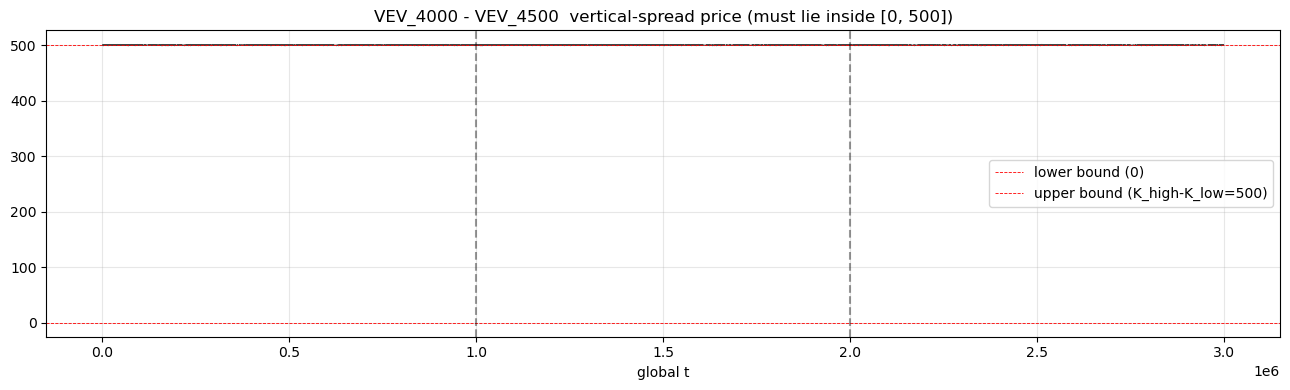

In [70]:
# Vertical-spread arbitrage: 0 <= C(K_low) - C(K_high) <= (K_high - K_low) for K_low < K_high.
arb_rows = []
for vL, vR in pairs:  # vL has lower strike than vR
    KL, KR = VOUCHER_STRIKES[vL], VOUCHER_STRIKES[vR]
    spread_price = mids[vL] - mids[vR]
    upper_bound = KR - KL
    n = spread_price.notna().sum()
    too_low = (spread_price < -0.5).sum()
    too_high = (spread_price > upper_bound + 0.5).sum()
    arb_rows.append(dict(
        pair=f"{vL}-{vR}", K_low=KL, K_high=KR, max_allowed=upper_bound,
        n=int(n),
        n_negative=int(too_low),
        n_above_strike_diff=int(too_high),
        min_spread=float(spread_price.min()),
        max_spread=float(spread_price.max()),
    ))
arb_df = pd.DataFrame(arb_rows)
print("Vertical-spread arbitrage scan (price spread vs strike spread):")
print(arb_df.to_string(index=False))

# Visualise the most-violated pair (if any).
if (arb_df["n_negative"] + arb_df["n_above_strike_diff"]).sum() > 0:
    worst = arb_df.iloc[(arb_df["n_negative"] + arb_df["n_above_strike_diff"]).idxmax()]
    vL, vR = worst["pair"].split("-")
    KL, KR = VOUCHER_STRIKES[vL], VOUCHER_STRIKES[vR]
    sp = mids[vL] - mids[vR]
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(sp.index, sp.values, lw=0.5, color="#444")
    ax.axhline(0, color="r", lw=0.6, ls="--", label="lower bound (0)")
    ax.axhline(KR - KL, color="r", lw=0.6, ls="--", label=f"upper bound (K_high-K_low={KR-KL})")
    ax.set_title(f"{vL} - {vR}  vertical-spread price (must lie inside [0, {KR-KL}])")
    ax.legend(); ax.set_xlabel("global t")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
    plt.tight_layout(); plt.show()


## 7. Spot-side microstructure (delta-1 mechanics)

Round-1 style microstructure analysis, restricted to the two delta-1 spot products. The vouchers are too discretized at the tick level for these signals to add value over IV-based strategies.

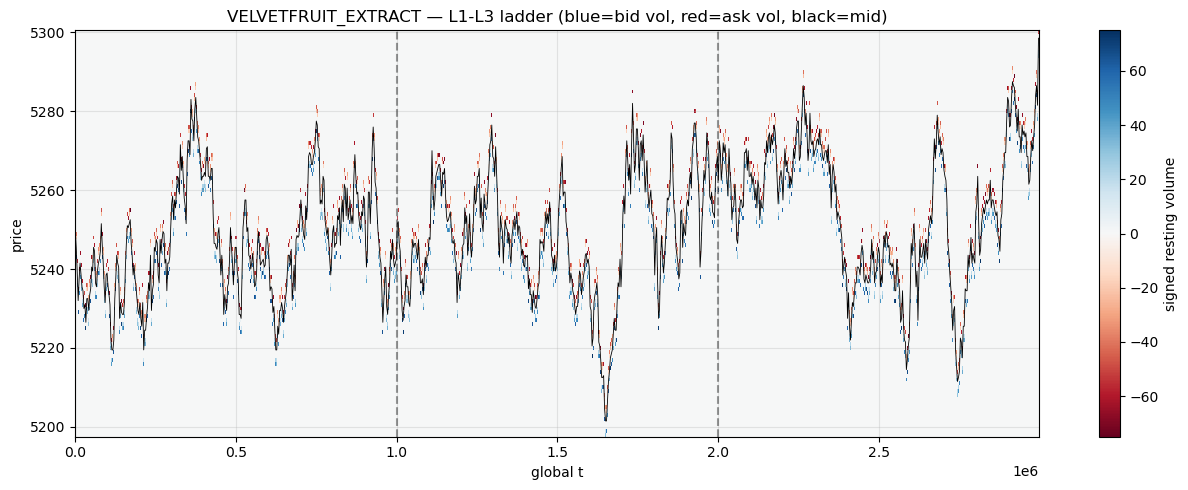

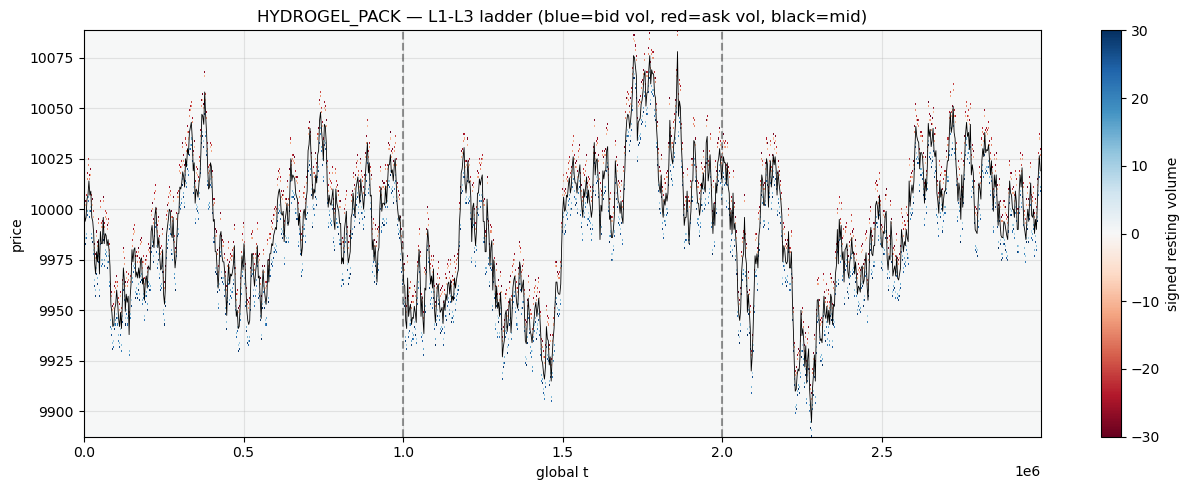

In [71]:
def book_heatmap(prices_df, product, tick_step=30, levels=3):
    sub = prices_df[prices_df["product"] == product].iloc[::tick_step].reset_index(drop=True)
    all_prices = []
    for lvl in range(1, levels + 1):
        all_prices += sub[f"bid_price_{lvl}"].dropna().astype(int).tolist()
        all_prices += sub[f"ask_price_{lvl}"].dropna().astype(int).tolist()
    if not all_prices:
        return
    p_min, p_max = min(all_prices), max(all_prices)
    price_axis = np.arange(p_min, p_max + 1)
    grid = np.zeros((len(price_axis), len(sub)))
    for j in range(len(sub)):
        row = sub.iloc[j]
        for lvl in range(1, levels + 1):
            bp, bv = row.get(f"bid_price_{lvl}"), row.get(f"bid_volume_{lvl}")
            ap, av = row.get(f"ask_price_{lvl}"), row.get(f"ask_volume_{lvl}")
            if pd.notna(bp) and pd.notna(bv):
                grid[int(bp) - p_min, j] += float(bv)
            if pd.notna(ap) and pd.notna(av):
                grid[int(ap) - p_min, j] -= float(av)
    fig, ax = plt.subplots(figsize=(13, 5))
    vmax = np.abs(grid).max() or 1
    im = ax.pcolormesh(sub["t"].values, price_axis, grid, cmap="RdBu", vmin=-vmax, vmax=vmax, shading="auto")
    ax.plot(sub["t"].values, sub["mid_price"].values, color="k", lw=0.6)
    ax.set_ylabel("price"); ax.set_xlabel("global t")
    ax.set_title(f"{product} — L1-L{levels} ladder (blue=bid vol, red=ask vol, black=mid)")
    for b in day_bounds[1:]:
        ax.axvline(b, color="k", ls="--", alpha=0.4)
    plt.colorbar(im, ax=ax, label="signed resting volume")
    plt.tight_layout(); plt.show()

for prod in PRODUCT_SPOT:
    book_heatmap(prices, prod)


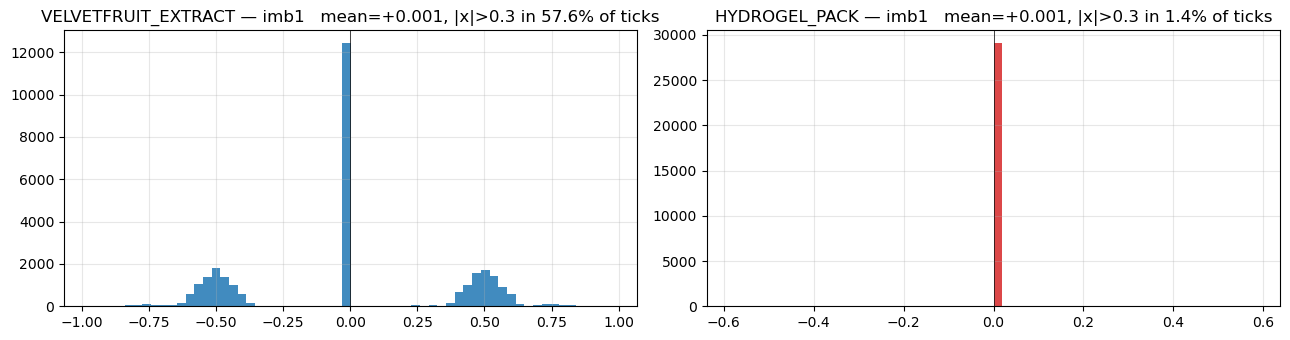

Mean next-tick Δmid per imb1 bucket:
                             mean    std  count
product       imb_bucket                       
HYDROGEL_PACK (-0.6, -0.3] -3.821  1.820    218
              (-0.3, -0.1] -4.007  1.839    205
              (-0.1, 0.1]  -0.008  2.061  29115
              (0.1, 0.3]    4.156  2.047    240
              (0.3, 0.6]    4.072  1.999    221
...                           ...    ...    ...
VEV_6000      (0.1, 0.3]    0.000  0.000     53
VEV_6500      (-0.6, -0.3]  0.000    NaN      1
              (-0.3, -0.1]  0.000  0.000    198
              (-0.1, 0.1]   0.000  0.000  29669
              (0.1, 0.3]    0.000  0.000    131

[75 rows x 3 columns]

Incremental R² per book level (next-tick Δmid):

  === VELVETFRUIT_EXTRACT  (n=29,999) ===
    R² using imb1..1  = 0.0788   coeffs=['+0.80', '+0.00']
    R² using imb1..2  = 0.0977   coeffs=['+0.71', '+2.21', '+0.00']
    R² using imb1..3  = 0.1365   coeffs=['+0.55', '+0.53', '-13.51', '+0.00']

  === HYDROGEL_PAC

In [72]:
# imb1 distribution + bucketed next-tick Δmid + L1/L2/L3 regression for spot pair.
sig = prices.copy().sort_values(["product", "t"])
sig = sig[(sig["mid_price"] > 0) & sig["mid_price"].notna()].reset_index(drop=True)
sig["imb1"] = agg_imb(sig, 1)
sig["imb2"] = agg_imb(sig, 2)
sig["imb3"] = agg_imb(sig, 3)
sig["ret_next"] = sig.groupby("product")["mid_price"].shift(-1) - sig["mid_price"]

# Distributions.
fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, prod in zip(axes, PRODUCT_SPOT):
    x = sig.loc[sig["product"] == prod, "imb1"].dropna()
    ax.hist(x, bins=60, color=SPOT_COLOR[prod], alpha=0.85)
    ax.axvline(0, color="k", lw=0.5)
    ax.set_title(f"{prod} — imb1   mean={x.mean():+.3f}, |x|>0.3 in {(x.abs()>0.3).mean()*100:.1f}% of ticks")
plt.tight_layout(); plt.show()

# Buckets.
BUCKETS = [-1.0, -0.6, -0.3, -0.1, 0.1, 0.3, 0.6, 1.0]
sig["imb_bucket"] = pd.cut(sig["imb1"], BUCKETS, include_lowest=True)
print("Mean next-tick Δmid per imb1 bucket:")
print(sig.groupby(["product", "imb_bucket"], observed=True)["ret_next"].agg(["mean", "std", "count"]).round(3))

# L1-L3 regression per spot product.
print("\nIncremental R² per book level (next-tick Δmid):")
for prod in PRODUCT_SPOT:
    sub = sig[sig["product"] == prod].dropna(subset=["imb1", "imb2", "imb3", "ret_next"])
    if len(sub) < 100:
        print(f"  {prod}: insufficient data"); continue
    y = sub["ret_next"].values
    ss_tot = float(np.sum((y - y.mean()) ** 2))
    print(f"\n  === {prod}  (n={len(sub):,}) ===")
    for kmax in (1, 2, 3):
        Xk = sub[[f"imb{i}" for i in range(1, kmax + 1)]].values
        Xka = np.c_[Xk, np.ones(len(Xk))]
        bk, *_ = np.linalg.lstsq(Xka, y, rcond=None)
        yhk = Xka @ bk
        r2k = 1.0 - float(np.sum((y - yhk) ** 2)) / ss_tot
        print(f"    R² using imb1..{kmax}  = {r2k:.4f}   coeffs={[f'{c:+.2f}' for c in bk]}")


In [73]:
# Spread-conditioned forward Δmid for spot pair.
sc = sig[sig["product"].isin(PRODUCT_SPOT)].copy()
sc["spread"] = prices.loc[sc.index, "ask_price_1"].values - prices.loc[sc.index, "bid_price_1"].values
EDGES = [0, 1, 2, 3, 4, 6, 10, 20, 200]
sc["spread_bucket"] = pd.cut(sc["spread"], EDGES, right=False)
tbl = (sc.dropna(subset=["ret_next", "spread"])
         .groupby(["product", "spread_bucket"], observed=True)["ret_next"]
         .agg(["count", "mean", "std"]).round(3))
print("Spread-conditioned next-tick Δmid:")
print(tbl)


Spread-conditioned next-tick Δmid:
                                   count   mean    std
product             spread_bucket                     
HYDROGEL_PACK       [1, 2)          8506  0.008  2.175
                    [2, 3)          4294 -0.006  2.178
                    [3, 4)          2473 -0.018  2.192
                    [4, 6)          4767 -0.030  2.132
                    [6, 10)         2597  0.017  2.178
                    [10, 20)        4910  0.045  2.170
                    [20, 200)       2452 -0.045  2.180
VELVETFRUIT_EXTRACT [1, 2)          8420  0.002  1.132
                    [2, 3)          3705 -0.015  1.141
                    [3, 4)          2854  0.005  1.123
                    [4, 6)          4640 -0.021  1.124
                    [6, 10)         3003  0.032  1.114
                    [10, 20)        4919  0.009  1.145
                    [20, 200)       2458  0.011  1.131


Trade aggressor summary (spot only):
                     n_trades  buy_agg_frac  sell_agg_frac  net_signed_qty  \
symbol                                                                       
HYDROGEL_PACK            1010         0.519          0.481             158   
VELVETFRUIT_EXTRACT      1372         0.569          0.431            1581   

                     gross_qty  
symbol                          
HYDROGEL_PACK             4078  
VELVETFRUIT_EXTRACT       8269  


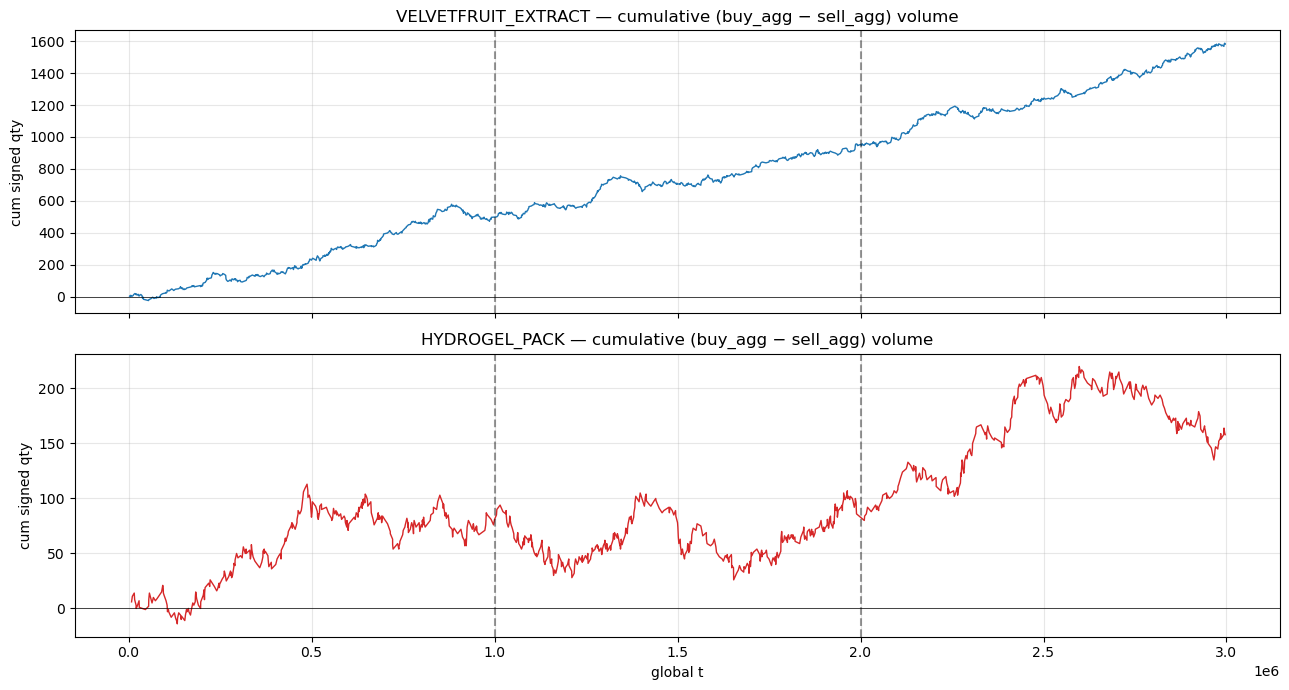

In [74]:
# Aggressor flow for VEV + HYDROGEL only.
trade_parts = []
for prod in PRODUCT_SPOT:
    mid_prod = prices[prices["product"] == prod][["t", "mid_price"]].dropna().sort_values("t")
    tr = trades[trades["symbol"] == prod][["t", "price", "quantity"]].sort_values("t")
    if len(tr) == 0:
        continue
    merged = pd.merge_asof(tr, mid_prod, on="t", direction="backward")
    merged["symbol"] = prod
    trade_parts.append(merged)
flow = pd.concat(trade_parts, ignore_index=True) if trade_parts else pd.DataFrame()

if len(flow):
    flow["sign"] = np.where(flow["price"] > flow["mid_price"], 1,
                     np.where(flow["price"] < flow["mid_price"], -1, 0))
    flow["signed_qty"] = flow["sign"] * flow["quantity"]
    summary_flow = flow.groupby("symbol").agg(
        n_trades=("quantity", "count"),
        buy_agg_frac=("sign", lambda s: (s == 1).mean()),
        sell_agg_frac=("sign", lambda s: (s == -1).mean()),
        net_signed_qty=("signed_qty", "sum"),
        gross_qty=("quantity", "sum"),
    ).round(3)
    print("Trade aggressor summary (spot only):")
    print(summary_flow)

    fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
    for ax, prod in zip(axes, PRODUCT_SPOT):
        sub = flow[flow["symbol"] == prod].sort_values("t")
        ax.plot(sub["t"], sub["signed_qty"].cumsum(), color=SPOT_COLOR[prod], lw=1.0)
        ax.axhline(0, color="k", lw=0.5)
        ax.set_title(f"{prod} — cumulative (buy_agg − sell_agg) volume")
        ax.set_ylabel("cum signed qty")
        for b in day_bounds[1:]:
            ax.axvline(b, color="k", ls="--", alpha=0.4)
    axes[-1].set_xlabel("global t")
    plt.tight_layout(); plt.show()


## 8. Takeaways — ranked alpha shortlist

After running the notebook, eyeball each section and rank what's strongest. The 1st-place 2024 team made ~100–150k/round on their **IV scalping** trade alone, so reproducing that playbook is the priority — everything else is a hedge.

**Tier 1 — IV scalping (1st place 2024)**
1. **Price-space smile residual + 1-lag ACF (§6.3.5)** — fit parabolic smile, get fitted IV `v̂(m)`, plug back into BS to get fair price, trade `mkt_mid − BS(v̂)`. Strong negative ACF(1) on `Δresidual` confirms scalping. Start with the strikes nearest ATM (5200–5400) and expand once thresholds are profitable. **This is the headline alpha.**
2. **Adjacent-strike IV Z-scores (§6.8)** — same thesis as #1 but pairs are cleaner if a single strike's data is too thin.

**Tier 2 — supporting trades**
3. **Vertical-spread arbitrage (§6.8)** — 2nd place 2024's voucher-pair angle. If `0 ≤ C(K_low) − C(K_high) ≤ K_high − K_low` is ever violated, take it — risk-free.
4. **ATM IV vs RV (§6.5)** — directional vol bet. Rich IV → short straddle, cheap IV → long straddle.
5. **Delta-hedged drift (§6.7)** — gamma scalping. Stable but small returns per the 2024 winners (kept them flat in all conditions).

**Tier 3 — mean-reversion side bet**
6. **VEV mean reversion (§4)** — fast EMA + fixed-threshold trade. 2024 winners considered this an "anti-regret" hedge against teams that go all-in on it. Sized small. 100k swings observed but also drawdowns of −50k.
7. **VEV `imb1` regression (§7)** — Round-1 microprice signal on the underlying. Modest, but composes naturally with the mean-reversion line.

**Tier 4 — independent product**
8. **HYDROGEL_PACK standalone (§7)** — its own asset class, not connected to vouchers. Run Round-1 microstructure playbook.

**Caveats**
- Deep-ITM (4000, 4500) and deep-OTM (6500) vouchers are too discretized at the tick level for IV-based signals — best treated as hedge instruments or excluded.
- Position limits cap each voucher at 300; size IV scalping bets so vega exposure across active strikes stays manageable.
- All IVs assume `r=0`. If the competition publishes a positive funding cost, re-derive.
- TTE shrinks each round (5d at start of Round 3 → 4d → 3d → 2d). Theta becomes brutal in the final 2 days; size down or close shorts before expiry approaches.
